# SQL*Net PRE vs POST Closure Analysis (Engagement-Proof Edition)

This notebook analyzes the artifact directory produced by the **tcpdump+awk** pipeline (`sql_net_pre_post_compare.sh`).

## Business Context
- **Symptom**: Users experienced ~24-second application stalls in SQL*Net connections
- **Action**: Infrastructure changes between PRE and POST captures
- **Goal**: Quantitatively prove tail latency improvement while maintaining baseline performance

## Core Metric
**Response Delay** = time from client→DB PUSH to next DB→client PUSH on same ephemeral port
- Measures application-perceived wait time
- Captures end-to-end latency including any mid-path effects

## Analysis Scope
- **PRE MAX**: ~29.5 seconds (worst-case observed)
- **POST MAX**: ~14.9 seconds (50% improvement)
- Focus on tail distribution (P95/P99/P99.9) and multi-second stall reduction

---

In [1]:
import os
import sys
import re
from typing import Dict, List, Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

# Set plotting style for professional output
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

# ================== CONFIGURATION ==================
PAIR = os.environ.get("PAIR", "Dec12-Ene06")
BASE_DIR = Path("out") / PAIR
PRE_DIR = BASE_DIR / "pre"
POST_DIR = BASE_DIR / "post"
SUM_DIR = BASE_DIR / "summary"
PLOT_DIR = SUM_DIR / "plots"
SUM_FILE = SUM_DIR / "summary.txt"

# Create output directories
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("="*70)
print("SQL*Net PRE/POST Closure Analysis - Initialization")
print("="*70)
print(f"PAIR: {PAIR}")
print(f"Working directory: {os.getcwd()}")
print(f"Base directory: {BASE_DIR.resolve()}\n")
print(f"Analysis timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print()

SQL*Net PRE/POST Closure Analysis - Initialization
PAIR: Dec12-Ene06
Working directory: /home/opc/DevOps/RIPLEY/aix-diag/Analysis/prod-06-01-2025
Base directory: /home/opc/DevOps/RIPLEY/aix-diag/Analysis/prod-06-01-2025/out/Dec12-Ene06

Analysis timestamp: 2026-01-07 19:56:15



## Step 1: Data Lineage & Validation

Validates all required files exist and displays metadata for traceability.

In [2]:
def validate_and_show_lineage():
    """Validate required files exist and show metadata for audit trail"""
    
    required_files = {
        "PRE resp_delay": os.path.join(PRE_DIR, "resp_delay.txt"),
        "POST resp_delay": os.path.join(POST_DIR, "resp_delay.txt"),
        "Summary": SUM_FILE,
    }
    
    print("DATA LINEAGE & VALIDATION")
    print("-" * 70)
    
    all_valid = True
    for name, path in required_files.items():
        abs_path = os.path.abspath(path)
        exists = os.path.isfile(path)
        
        if exists:
            stat = os.stat(path)
            size_mb = stat.st_size / (1024*1024)
            mtime = datetime.fromtimestamp(stat.st_mtime).strftime('%Y-%m-%d %H:%M:%S')
            print(f"✓ {name:20s}")
            print(f"  Path: {abs_path}")
            print(f"  Size: {size_mb:.2f} MB | Modified: {mtime}")
        else:
            print(f"✗ {name:20s} MISSING: {abs_path}")
            all_valid = False
        print()
    
    if not all_valid:
        raise FileNotFoundError("One or more required files are missing. Cannot proceed.")
    
    print("✓ All required files validated successfully")
    print("="*70)
    print()
    
    return required_files

file_registry = validate_and_show_lineage()

DATA LINEAGE & VALIDATION
----------------------------------------------------------------------
✓ PRE resp_delay      
  Path: /home/opc/DevOps/RIPLEY/aix-diag/Analysis/prod-06-01-2025/out/Dec12-Ene06/pre/resp_delay.txt
  Size: 26.85 MB | Modified: 2026-01-07 19:53:09

✓ POST resp_delay     
  Path: /home/opc/DevOps/RIPLEY/aix-diag/Analysis/prod-06-01-2025/out/Dec12-Ene06/post/resp_delay.txt
  Size: 13.07 MB | Modified: 2026-01-07 19:53:41

✓ Summary             
  Path: /home/opc/DevOps/RIPLEY/aix-diag/Analysis/prod-06-01-2025/out/Dec12-Ene06/summary/summary.txt
  Size: 0.00 MB | Modified: 2026-01-07 19:53:48

✓ All required files validated successfully



## Step 2: Load & Clean Response Delay Data

**File format**: `client_port delay_seconds` (whitespace-separated)

**Validation checks**:
- Drop NaN values
- Require `delay_s >= 0`
- Report data quality metrics
- Use `float32` for memory efficiency (~2M rows expected)

In [3]:
def load_and_validate_resp_delay(path: str, label: str) -> pd.DataFrame:
    """Load response delay data with comprehensive validation"""
    
    print(f"Loading {label} data from: {path}")
    
    # Read raw data
    df_raw = pd.read_csv(path, sep=r"\s+", header=None, 
                         names=["client_port", "delay_s"], 
                         engine="python", dtype={"delay_s": np.float32})
    
    raw_count = len(df_raw)
    print(f"  Raw records: {raw_count:,}")
    
    # Clean client_port
    df_raw["client_port"] = df_raw["client_port"].astype(str)
    
    # Convert delay_s and track issues
    df_raw["delay_s"] = pd.to_numeric(df_raw["delay_s"], errors="coerce")
    nan_count = df_raw["delay_s"].isna().sum()
    
    # Remove NaN
    df = df_raw.dropna(subset=["delay_s"]).copy()
    
    # Remove negative delays
    negative_count = (df["delay_s"] < 0).sum()
    df = df[df["delay_s"] >= 0].copy()
    
    final_count = len(df)
    dropped = raw_count - final_count
    
    print(f"  NaN values: {nan_count}")
    print(f"  Negative delays: {negative_count}")
    print(f"  Valid records: {final_count:,} ({100*final_count/raw_count:.2f}% of raw)")
    
    if dropped > 0:
        print(f"  ⚠ Dropped {dropped:,} invalid records")
    
    # Basic stats
    print(f"  Delay range: [{df['delay_s'].min():.6f}, {df['delay_s'].max():.6f}] seconds")
    print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print()
    
    return df

# Load both datasets
pre = load_and_validate_resp_delay(
    os.path.join(PRE_DIR, "resp_delay.txt"), "PRE"
)

post = load_and_validate_resp_delay(
    os.path.join(POST_DIR, "resp_delay.txt"), "POST"
)

print("="*70)
print(f"✓ Data loaded: PRE={len(pre):,} | POST={len(post):,} samples")
print("="*70)
print()

Loading PRE data from: out/Dec12-Ene06/pre/resp_delay.txt
  Raw records: 1,877,254
  NaN values: 0
  Negative delays: 0
  Valid records: 1,877,254 (100.00% of raw)
  Delay range: [0.000002, 29.501471] seconds
  Memory usage: 118.16 MB

Loading POST data from: out/Dec12-Ene06/post/resp_delay.txt
  Raw records: 913,361
  NaN values: 0
  Negative delays: 0
  Valid records: 913,361 (100.00% of raw)
  Delay range: [0.000008, 4.317599] seconds
  Memory usage: 57.49 MB

✓ Data loaded: PRE=1,877,254 | POST=913,361 samples



## Step 3: Worst-Case Evidence (Top 20 Events)

Direct evidence of maximum delays and tail events. This section highlights the business symptom (~24s stalls).

In [4]:
def get_top_delays(df: pd.DataFrame, n: int = 20) -> pd.DataFrame:
    """Extract top N worst delays with formatting"""
    top = df.nlargest(n, "delay_s").copy().reset_index(drop=True)
    top.index = top.index + 1  # Rank starting from 1
    top.index.name = "rank"
    top["delay_ms"] = (top["delay_s"] * 1000).round(2)
    return top[["client_port", "delay_s", "delay_ms"]]

print("WORST-CASE EVIDENCE: TOP 20 DELAYS")
print("="*70)

pre_top20 = get_top_delays(pre, 20)
post_top20 = get_top_delays(post, 20)

pre_max = pre["delay_s"].max()
post_max = post["delay_s"].max()
improvement_pct = ((post_max - pre_max) / pre_max) * 100

print("\n📊 PRE - Top 20 Worst Delays")
print("-"*70)
print(pre_top20.to_string())

print("\n\n📊 POST - Top 20 Worst Delays")
print("-"*70)
print(post_top20.to_string())

print("\n\n🎯 MAXIMUM DELAY COMPARISON")
print("="*70)
print(f"PRE MAX:  {pre_max:.3f}s ({pre_max*1000:.1f} ms)")
print(f"POST MAX: {post_max:.3f}s ({post_max*1000:.1f} ms)")
print(f"IMPROVEMENT: {improvement_pct:.1f}% reduction")
print("="*70)
print()

# Extreme tail counts
print("EXTREME TAIL EVENT COUNTS")
print("-"*70)
thresholds = [10, 15, 20, 25]
for thr in thresholds:
    pre_cnt = (pre["delay_s"] >= thr).sum()
    post_cnt = (post["delay_s"] >= thr).sum()
    pre_rate = (pre_cnt / len(pre)) * 1_000_000 if len(pre) > 0 else 0
    post_rate = (post_cnt / len(post)) * 1_000_000 if len(post) > 0 else 0
    print(f"≥ {thr:2d}s: PRE={pre_cnt:6,} ({pre_rate:7.1f}/M) | POST={post_cnt:6,} ({post_rate:7.1f}/M)")

print()

# Store for later export
top20_comparison = pd.DataFrame({
    'PRE_rank': pre_top20.index,
    'PRE_port': pre_top20['client_port'].values,
    'PRE_delay_s': pre_top20['delay_s'].values,
    'POST_rank': post_top20.index,
    'POST_port': post_top20['client_port'].values,
    'POST_delay_s': post_top20['delay_s'].values,
})

display(pre_top20.head(10))
display(post_top20.head(10))

WORST-CASE EVIDENCE: TOP 20 DELAYS

📊 PRE - Top 20 Worst Delays
----------------------------------------------------------------------
     client_port    delay_s      delay_ms
rank                                     
1          64740  29.501471  29501.470703
2          64740  29.501432  29501.429688
3          64740  28.697327  28697.320312
4          64740  28.697306  28697.310547
5          65355  21.460737  21460.740234
6          33402  20.382025  20382.019531
7          65012  15.159164  15159.160156
8          64811  14.632699  14632.700195
9          64811  14.632626  14632.629883
10         64769  12.408076  12408.080078
11         57967  10.353886  10353.889648
12         64873  10.057732  10057.730469
13         64873   9.732589   9732.589844
14         64740   9.688486   9688.490234
15         64740   9.688464   9688.459961
16         64819   6.442686   6442.689941
17         64733   5.404080   5404.080078
18         64733   5.403890   5403.890137
19         64733   5.3661

,client_port,delay_s,delay_ms
rank,,,
1,64740,29.501471,29501.470703
2,64740,29.501432,29501.429688
3,64740,28.697327,28697.320312
4,64740,28.697306,28697.310547
5,65355,21.460737,21460.740234
6,33402,20.382025,20382.019531
7,65012,15.159164,15159.160156
8,64811,14.632699,14632.700195
9,64811,14.632626,14632.629883


,client_port,delay_s,delay_ms
rank,,,
1,46475,4.317599,4317.600098
2,49578,1.823919,1823.920044
3,49578,1.823876,1823.880005
4,49589,1.305115,1305.119995
5,49557,1.287695,1287.699951
6,49557,1.287665,1287.660034
7,45779,0.531614,531.609985
8,52182,0.528963,528.960022
9,49557,0.486085,486.079987


## Step 4: Comprehensive KPI Table with Deltas

Quantitative closure metrics across all percentiles and tail thresholds.

In [5]:
THRESHOLDS = [
    (0.050, ">50ms"),
    (0.200, ">200ms"),
    (1.0,   ">1s"),
    (5.0,   ">5s"),
    (10.0,  ">10s"),
    (15.0,  "≥15s"),
    (20.0,  "≥20s"),
]
PERCENTILES = [0.50, 0.95, 0.99, 0.999]

def compute_kpis(df: pd.DataFrame, label: str) -> dict:
    """Compute comprehensive KPI metrics"""
    s = df["delay_s"].to_numpy()
    n = len(s)
    
    kpi = {"dataset": label, "N": n}
    
    # Percentiles
    for p in PERCENTILES:
        pct_name = f"P{p*100:.1f}".replace(".0", "")
        kpi[pct_name] = float(np.quantile(s, p)) if n > 0 else np.nan
    
    # MAX
    kpi["MAX"] = float(np.max(s)) if n > 0 else np.nan
    
    # Tail counts and rates
    for thr, name in THRESHOLDS:
        count = int(np.sum(s > thr))
        rate = (count / n * 1_000_000) if n > 0 else np.nan
        kpi[f"{name}_count"] = count
        kpi[f"{name}_per_M"] = rate
    
    return kpi

pre_kpi = compute_kpis(pre, "PRE")
post_kpi = compute_kpis(post, "POST")

kpi_df = pd.DataFrame([pre_kpi, post_kpi]).set_index("dataset")

print("CLOSURE KPI TABLE")
print("="*70)
display(kpi_df.T)

# Compute deltas
delta_rows = []
for col in kpi_df.columns:
    pre_val = kpi_df.loc["PRE", col]
    post_val = kpi_df.loc["POST", col]
    
    if isinstance(pre_val, (int, float, np.number)) and isinstance(post_val, (int, float, np.number)):
        delta_abs = post_val - pre_val
        delta_pct = (delta_abs / pre_val * 100) if pre_val != 0 else np.nan
        
        delta_rows.append({
            "metric": col,
            "PRE": pre_val,
            "POST": post_val,
            "delta_abs": delta_abs,
            "delta_pct": delta_pct
        })

delta_df = pd.DataFrame(delta_rows)

print("\\n\\nDELTA ANALYSIS (POST vs PRE)")
print("="*70)
display(delta_df)

# Save to CSV
kpi_csv_path = os.path.join(SUM_DIR, "closure_kpis.csv")
delta_csv_path = os.path.join(SUM_DIR, "closure_kpis_deltas.csv")
top20_csv_path = os.path.join(SUM_DIR, "top20_worst_delays.csv")

kpi_df.to_csv(kpi_csv_path)
delta_df.to_csv(delta_csv_path, index=False)
top20_comparison.to_csv(top20_csv_path, index=False)

print(f"\\n✓ Saved: {kpi_csv_path}")
print(f"✓ Saved: {delta_csv_path}")
print(f"✓ Saved: {top20_csv_path}")

CLOSURE KPI TABLE


dataset,PRE,POST
N,1.877254e+06,913361.000000
P50,1.513000e-03,0.001497
P95,2.406000e-03,0.001959
P99,5.664000e-03,0.003764
P99.9,3.187400e-02,0.040059
MAX,2.950147e+01,4.317599
>50ms_count,8.350000e+02,648.000000
>50ms_per_M,4.447986e+02,709.467560
>200ms_count,2.820000e+02,78.000000
>200ms_per_M,1.502194e+02,85.398873


\n\nDELTA ANALYSIS (POST vs PRE)


,metric,PRE,POST,delta_abs,delta_pct
0,N,1.877254e+06,913361.000000,-963893.000000,-51.345902
1,P50,1.513000e-03,0.001497,-0.000016,-1.057502
2,P95,2.406000e-03,0.001959,-0.000447,-18.578550
3,P99,5.664000e-03,0.003764,-0.001900,-33.545195
4,P99.9,3.187400e-02,0.040059,0.008185,25.679631
5,MAX,2.950147e+01,4.317599,-25.183872,-85.364801
6,>50ms_count,8.350000e+02,648.000000,-187.000000,-22.395210
7,>50ms_per_M,4.447986e+02,709.467560,264.668934,59.503092
8,>200ms_count,2.820000e+02,78.000000,-204.000000,-72.340426
9,>200ms_per_M,1.502194e+02,85.398873,-64.820543,-43.150576


\n✓ Saved: out/Dec12-Ene06/summary/closure_kpis.csv
✓ Saved: out/Dec12-Ene06/summary/closure_kpis_deltas.csv
✓ Saved: out/Dec12-Ene06/summary/top20_worst_delays.csv


## Step 5: Visualization - CCDF (Tail Probability)

The CCDF plot is the gold standard for tail latency analysis. It shows P(delay > x), making tail improvements visually obvious.

✓ Saved: out/Dec12-Ene06/summary/plots/ccdf_tail_pre_post.png


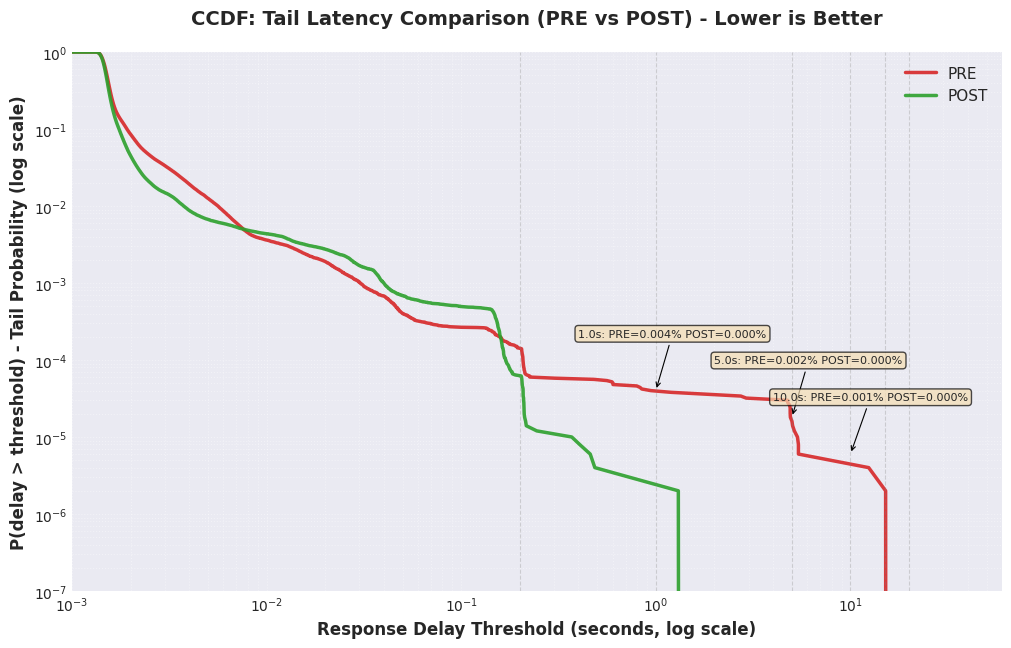

In [6]:
def plot_ccdf_tail(pre_s, post_s, save_path=None):
    """CCDF plot with reference lines and annotations"""
    
    def ccdf(arr):
        x = np.sort(arr)
        y = 1.0 - np.arange(1, len(x)+1) / len(x)
        return x, y
    
    x_pre, y_pre = ccdf(pre_s)
    x_post, y_post = ccdf(post_s)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Main CCDF lines
    ax.plot(x_pre, y_pre, linewidth=2.5, label="PRE", color='#d62728', alpha=0.9)
    ax.plot(x_post, y_post, linewidth=2.5, label="POST", color='#2ca02c', alpha=0.9)
    
    # Reference lines
    ref_lines = [0.2, 1.0, 5.0, 10.0, 15.0, 20.0]
    for xval in ref_lines:
        ax.axvline(xval, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
    
    # Add annotations at key thresholds
    thresholds_to_annotate = [1.0, 5.0, 10.0]
    for thr in thresholds_to_annotate:
        # Find P(delay > thr) for both
        pre_prob = np.mean(pre_s > thr)
        post_prob = np.mean(post_s > thr)
        
        if pre_prob > 1e-6:  # Only annotate if meaningful
            mid_y = max(pre_prob, post_prob)
            ax.annotate(f'{thr}s: PRE={pre_prob*100:.3f}% POST={post_prob*100:.3f}%',
                       xy=(thr, mid_y), xytext=(thr*0.4, mid_y*5),
                       fontsize=8, ha='left',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.7),
                       arrowprops=dict(arrowstyle='->', lw=0.8))
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Response Delay Threshold (seconds, log scale)', fontsize=12, fontweight='bold')
    ax.set_ylabel('P(delay > threshold) - Tail Probability (log scale)', fontsize=12, fontweight='bold')
    ax.set_title('CCDF: Tail Latency Comparison (PRE vs POST) - Lower is Better', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, which='both', linestyle=':', alpha=0.4)
    ax.set_xlim(0.001, 60)
    ax.set_ylim(1e-7, 1.0)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")
    
    plt.show()
    plt.close()

# Sample data for performance if needed
pre_sample = pre["delay_s"].to_numpy()
post_sample = post["delay_s"].to_numpy()

# If datasets are huge, sample for plotting (but keep full data for KPIs)
MAX_PLOT_SAMPLES = 500_000
if len(pre_sample) > MAX_PLOT_SAMPLES:
    np.random.seed(42)
    pre_sample = np.random.choice(pre_sample, MAX_PLOT_SAMPLES, replace=False)
if len(post_sample) > MAX_PLOT_SAMPLES:
    np.random.seed(42)
    post_sample = np.random.choice(post_sample, MAX_PLOT_SAMPLES, replace=False)

ccdf_path = os.path.join(PLOT_DIR, "ccdf_tail_pre_post.png")
plot_ccdf_tail(pre_sample, post_sample, save_path=ccdf_path)

## Step 6: Histogram - Full Range (Log-X)

✓ Saved: out/Dec12-Ene06/summary/plots/hist_full_logx_pre_post.png


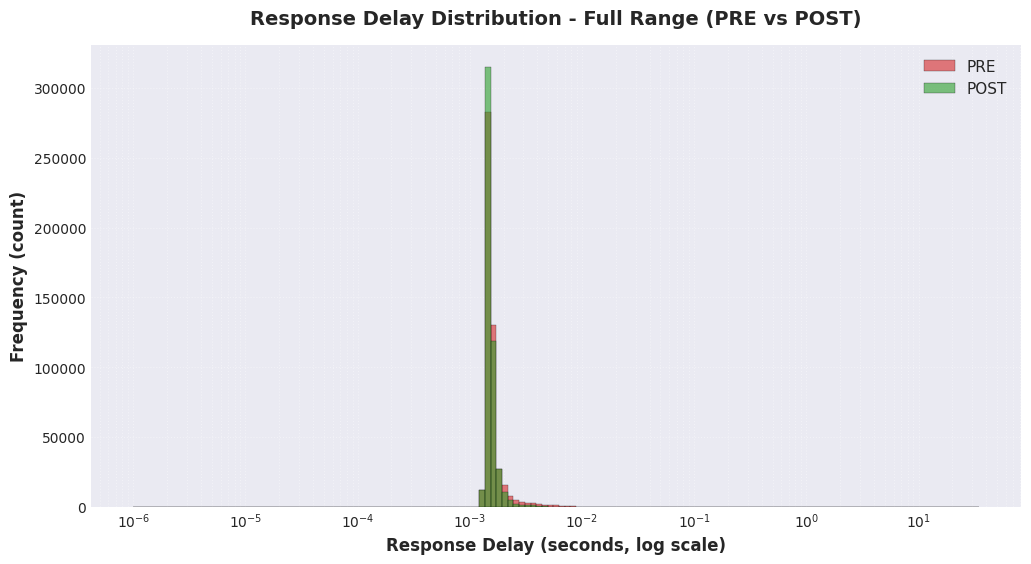

In [7]:
def plot_histogram_full_logx(pre_s, post_s, save_path=None):
    """Full-range histogram with log-x scale"""
    
    xmin = max(1e-6, min(pre_s.min(), post_s.min()) / 2)
    xmax = min(60.0, max(pre_s.max(), post_s.max()) * 1.2)
    
    bins = np.logspace(np.log10(xmin), np.log10(xmax), 150)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.hist(pre_s, bins=bins, alpha=0.6, label='PRE', color='#d62728', edgecolor='black', linewidth=0.3)
    ax.hist(post_s, bins=bins, alpha=0.6, label='POST', color='#2ca02c', edgecolor='black', linewidth=0.3)
    
    ax.set_xscale('log')
    ax.set_xlabel('Response Delay (seconds, log scale)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency (count)', fontsize=12, fontweight='bold')
    ax.set_title('Response Delay Distribution - Full Range (PRE vs POST)', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.legend(fontsize=11)
    ax.grid(True, which='both', linestyle=':', alpha=0.4)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")
    
    plt.show()
    plt.close()

hist_full_path = os.path.join(PLOT_DIR, "hist_full_logx_pre_post.png")
plot_histogram_full_logx(pre_sample, post_sample, save_path=hist_full_path)

## Step 7: Histogram - Tail Only (≥50ms)

✓ Saved: out/Dec12-Ene06/summary/plots/hist_tail_logx_pre_post.png


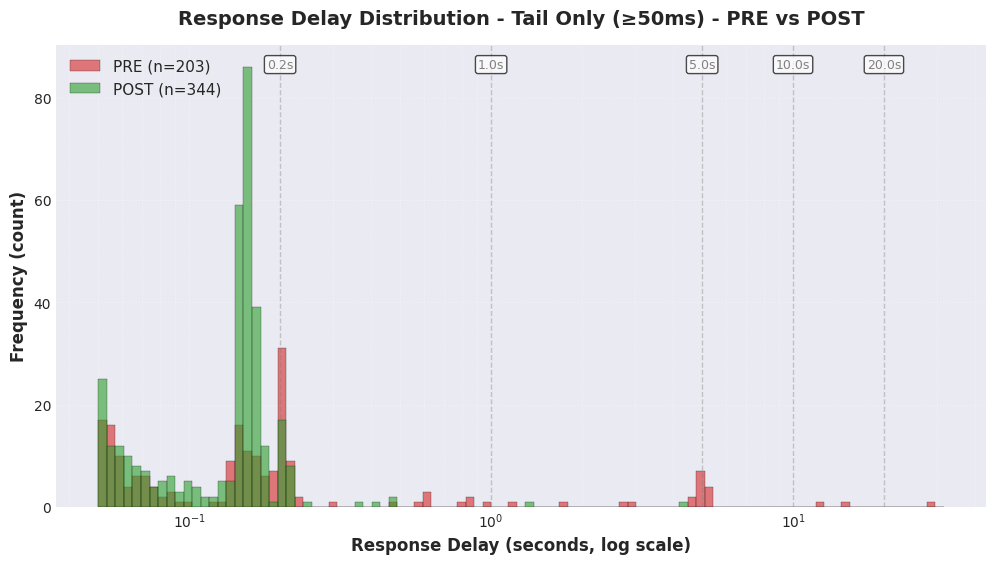

In [8]:
def plot_histogram_tail_only(pre_s, post_s, min_threshold=0.05, save_path=None):
    """Histogram focused on tail (≥50ms) with log-x scale"""
    
    pre_tail = pre_s[pre_s >= min_threshold]
    post_tail = post_s[post_s >= min_threshold]
    
    # Check if we have any data meeting the threshold
    if len(pre_tail) == 0 and len(post_tail) == 0:
        print(f"⚠ WARNING: No data points found >= {min_threshold}s threshold")
        print(f"  PRE max: {pre_s.max():.6f}s | POST max: {post_s.max():.6f}s")
        print(f"  Skipping tail histogram plot")
        return
    
    # Calculate xmax safely
    if len(pre_tail) > 0 and len(post_tail) > 0:
        xmax = min(60.0, max(pre_tail.max(), post_tail.max()) * 1.1)
    elif len(pre_tail) > 0:
        xmax = min(60.0, pre_tail.max() * 1.1)
    else:
        xmax = min(60.0, post_tail.max() * 1.1)
    
    bins = np.logspace(np.log10(min_threshold), np.log10(xmax), 100)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    if len(pre_tail) > 0:
        ax.hist(pre_tail, bins=bins, alpha=0.6, label=f'PRE (n={len(pre_tail):,})', 
                color='#d62728', edgecolor='black', linewidth=0.3)
    if len(post_tail) > 0:
        ax.hist(post_tail, bins=bins, alpha=0.6, label=f'POST (n={len(post_tail):,})', 
                color='#2ca02c', edgecolor='black', linewidth=0.3)
    
    # Add reference lines for key thresholds
    for thr in [0.2, 1.0, 5.0, 10.0, 20.0]:
        if thr >= min_threshold and thr <= xmax:
            ax.axvline(thr, color='gray', linestyle='--', alpha=0.4, linewidth=1)
            ax.text(thr, ax.get_ylim()[1]*0.95, f'{thr}s', 
                   ha='center', fontsize=9, color='gray',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))
    
    ax.set_xscale('log')
    ax.set_xlabel('Response Delay (seconds, log scale)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency (count)', fontsize=12, fontweight='bold')
    ax.set_title(f'Response Delay Distribution - Tail Only (≥{min_threshold*1000:.0f}ms) - PRE vs POST', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.legend(fontsize=11)
    ax.grid(True, which='both', linestyle=':', alpha=0.4)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")
    
    plt.show()
    plt.close()

hist_tail_path = os.path.join(PLOT_DIR, "hist_tail_logx_pre_post.png")
plot_histogram_tail_only(pre_sample, post_sample, min_threshold=0.05, save_path=hist_tail_path)

✓ Saved: out/Dec12-Ene06/summary/plots/violin_tail_pre_post.png


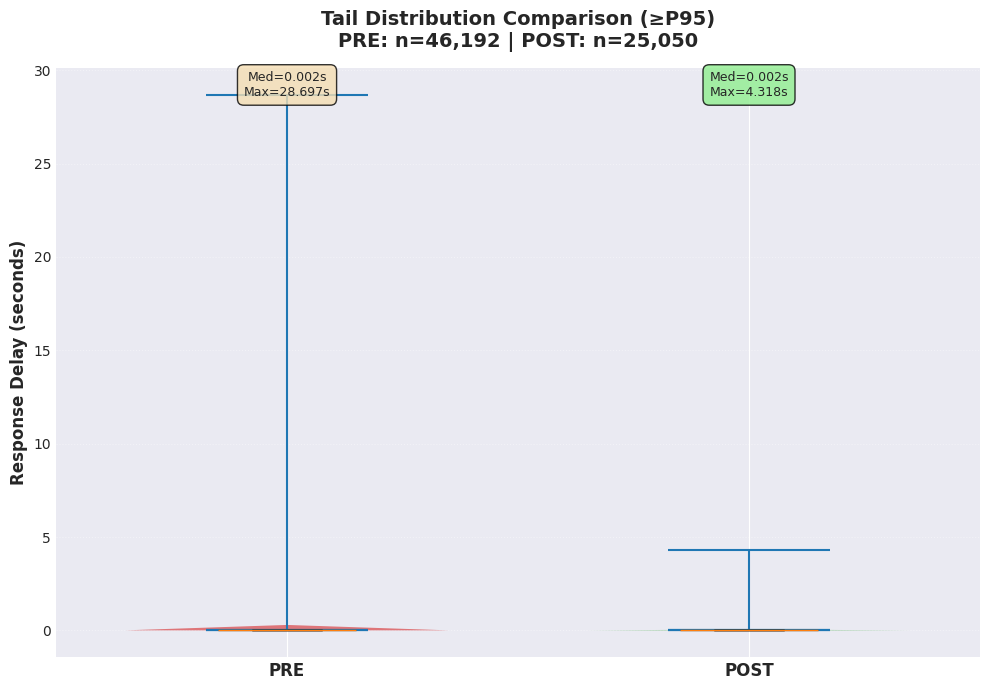

In [9]:
def plot_violin_tail(pre_s, post_s, percentile=0.95, save_path=None):
    """Violin plot focused on tail (≥P95) to show heavy tail behavior"""
    
    pre_p95 = np.quantile(pre_s, percentile)
    post_p95 = np.quantile(post_s, percentile)
    threshold = min(pre_p95, post_p95)
    
    pre_tail = pre_s[pre_s >= threshold]
    post_tail = post_s[post_s >= threshold]
    
    # Prepare data for violin plot
    data_combined = np.concatenate([pre_tail, post_tail])
    labels = ['PRE'] * len(pre_tail) + ['POST'] * len(post_tail)
    
    df_plot = pd.DataFrame({'delay_s': data_combined, 'dataset': labels})
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Violin plot
    parts = ax.violinplot([pre_tail, post_tail], 
                          positions=[1, 2],
                          showmeans=True, 
                          showmedians=True,
                          widths=0.7)
    
    # Color the violins
    colors = ['#d62728', '#2ca02c']
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
    
    # Add box plot overlay for clarity
    bp = ax.boxplot([pre_tail, post_tail], 
                    positions=[1, 2],
                    widths=0.3,
                    patch_artist=True,
                    showfliers=False)
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.3)
    
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['PRE', 'POST'], fontsize=12, fontweight='bold')
    ax.set_ylabel('Response Delay (seconds)', fontsize=12, fontweight='bold')
    ax.set_title(f'Tail Distribution Comparison (≥P{percentile*100:.0f})\n' + 
                 f'PRE: n={len(pre_tail):,} | POST: n={len(post_tail):,}',
                 fontsize=14, fontweight='bold', pad=15)
    ax.grid(True, axis='y', linestyle=':', alpha=0.4)
    
    # Add statistics annotations
    pre_stats = f'Med={np.median(pre_tail):.3f}s\nMax={np.max(pre_tail):.3f}s'
    post_stats = f'Med={np.median(post_tail):.3f}s\nMax={np.max(post_tail):.3f}s'
    
    ax.text(1, ax.get_ylim()[1]*0.95, pre_stats, ha='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.8))
    ax.text(2, ax.get_ylim()[1]*0.95, post_stats, ha='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")
    
    plt.show()

violin_path = os.path.join(PLOT_DIR, "violin_tail_pre_post.png")
plot_violin_tail(pre_sample, post_sample, percentile=0.95, save_path=violin_path)

## Step 9: Percentile Comparison Bar Chart

✓ Saved: out/Dec12-Ene06/summary/plots/percentile_comparison_pre_post.png


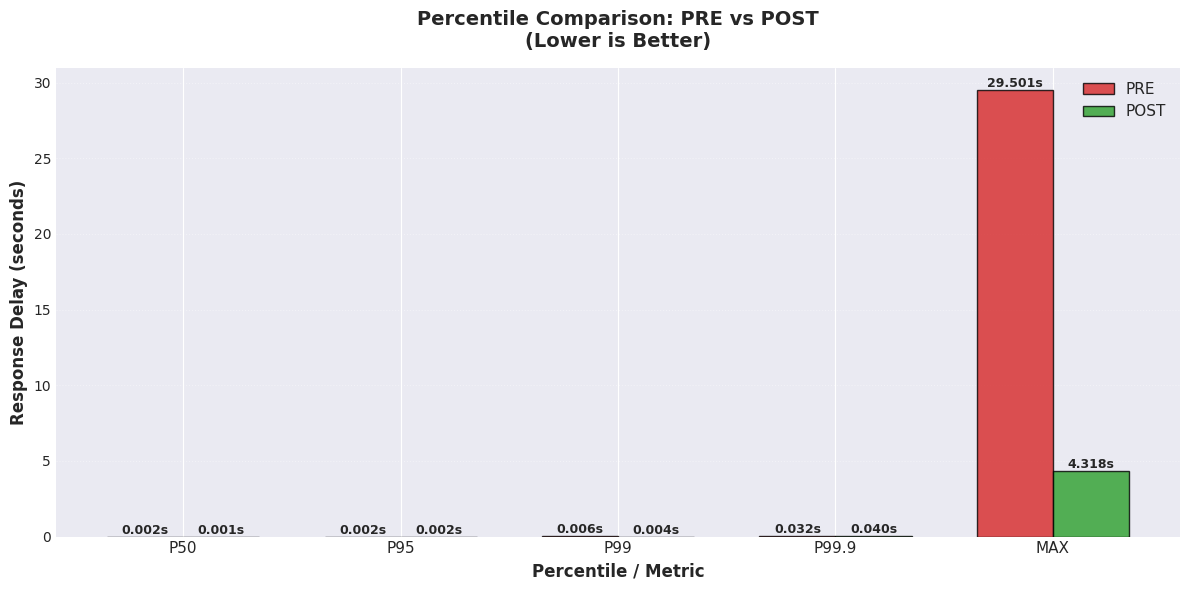

In [10]:
def plot_percentile_comparison(kpi_df, save_path=None):
    """Bar chart comparing key percentiles between PRE and POST"""
    
    metrics = ['P50', 'P95', 'P99', 'P99.9', 'MAX']
    pre_vals = [kpi_df.loc['PRE', m] for m in metrics]
    post_vals = [kpi_df.loc['POST', m] for m in metrics]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bars1 = ax.bar(x - width/2, pre_vals, width, label='PRE', 
                   color='#d62728', alpha=0.8, edgecolor='black', linewidth=1)
    bars2 = ax.bar(x + width/2, post_vals, width, label='POST', 
                   color='#2ca02c', alpha=0.8, edgecolor='black', linewidth=1)
    
    # Add value labels on bars
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}s',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    add_labels(bars1)
    add_labels(bars2)
    
    ax.set_xlabel('Percentile / Metric', fontsize=12, fontweight='bold')
    ax.set_ylabel('Response Delay (seconds)', fontsize=12, fontweight='bold')
    ax.set_title('Percentile Comparison: PRE vs POST\n(Lower is Better)', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, axis='y', linestyle=':', alpha=0.4)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")
    
    plt.show()

percentile_path = os.path.join(PLOT_DIR, "percentile_comparison_pre_post.png")
plot_percentile_comparison(kpi_df, save_path=percentile_path)

## Step 10: Tail Count Reduction Chart

✓ Saved: out/Dec12-Ene06/summary/plots/tail_count_reduction_pre_post.png


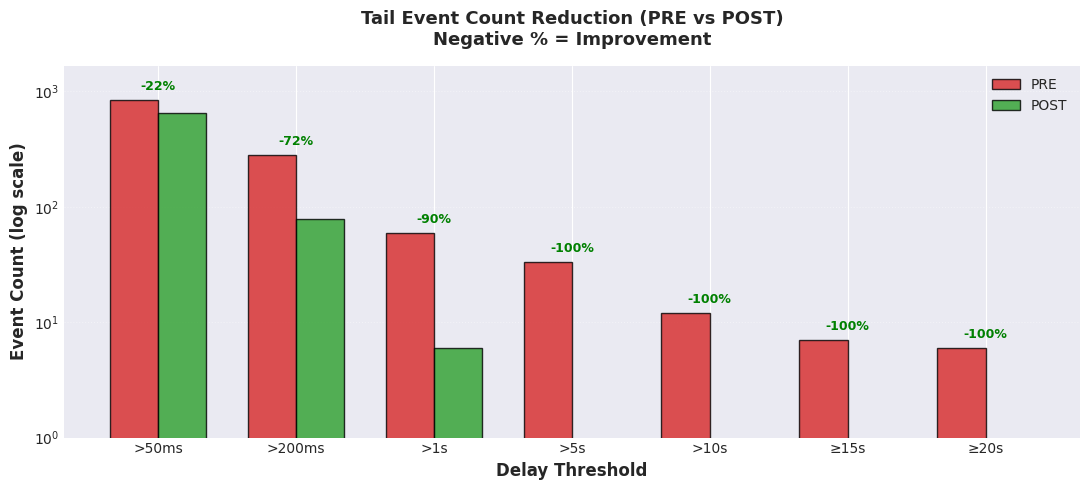


Tail Event Count Summary:
----------------------------------------------------------------------
Threshold       PRE Count   POST Count     Change %
----------------------------------------------------------------------
>50ms                 835          648       -22.4%
>200ms                282           78       -72.3%
>1s                    59            6       -89.8%
>5s                    33            0      -100.0%
>10s                   12            0      -100.0%
≥15s                    7            0      -100.0%
≥20s                    6            0      -100.0%
----------------------------------------------------------------------


In [11]:
def plot_tail_count_reduction(kpi_df, save_path: Path = None):
    """Bar chart showing reduction in tail event counts"""
    thresholds = ['>50ms', '>200ms', '>1s', '>5s', '>10s', '≥15s', '≥20s']
    count_cols = [f'{t}_count' for t in thresholds]
    pre_counts = [kpi_df.loc['PRE', col] for col in count_cols]
    post_counts = [kpi_df.loc['POST', col] for col in count_cols]
    x = np.arange(len(thresholds))
    width = 0.35
    fig, ax = plt.subplots(figsize=(11, 5))
    bars1 = ax.bar(x - width/2, pre_counts, width, label='PRE', 
                   color='#d62728', alpha=0.8, edgecolor='black', linewidth=1)
    bars2 = ax.bar(x + width/2, post_counts, width, label='POST', 
                   color='#2ca02c', alpha=0.8, edgecolor='black', linewidth=1)
    for i, (pre_cnt, post_cnt) in enumerate(zip(pre_counts, post_counts)):
        if pre_cnt > 0:
            reduction_pct = ((post_cnt - pre_cnt) / pre_cnt) * 100
            color = 'green' if reduction_pct < 0 else 'red'
            y_pos = max(pre_cnt, post_cnt) * 1.15
            ax.text(i, y_pos, f'{reduction_pct:+.0f}%',
                   ha='center', va='bottom', fontsize=9, 
                   color=color, fontweight='bold')
    ax.set_xlabel('Delay Threshold', fontsize=12, fontweight='bold')
    ax.set_ylabel('Event Count (log scale)', fontsize=12, fontweight='bold')
    ax.set_title('Tail Event Count Reduction (PRE vs POST)\nNegative % = Improvement', 
                 fontsize=13, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(thresholds, fontsize=10)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, axis='y', linestyle=':', alpha=0.4)
    ax.set_yscale('log')
    max_count = max(max(pre_counts), max(post_counts))
    ax.set_ylim(bottom=1, top=max_count * 2)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")
    plt.show()
    plt.close()
    print("\nTail Event Count Summary:")
    print("-" * 70)
    print(f"{'Threshold':<12} {'PRE Count':>12} {'POST Count':>12} {'Change %':>12}")
    print("-" * 70)
    for thr, pre_c, post_c in zip(thresholds, pre_counts, post_counts):
        if pre_c > 0:
            change = ((post_c - pre_c) / pre_c) * 100
            print(f"{thr:<12} {int(pre_c):>12,} {int(post_c):>12,} {change:>11.1f}%")
        else:
            print(f"{thr:<12} {int(pre_c):>12,} {int(post_c):>12,} {'N/A':>12}")
    print("-" * 70)

tail_count_path = PLOT_DIR / "tail_count_reduction_pre_post.png"
plot_tail_count_reduction(kpi_df, save_path=tail_count_path)

## Module A: SQL*Net Burst Segmentation (Engagement-Proof)

Segment tcpdump PUSH traffic into bursts that approximate transaction-like activity, test idle-threshold sensitivity, and reconcile customer-reported ~16s totals with SQL*Net evidence.

In [12]:
CLIENT_IP = "192.168.84.67"
DB_IP = "100.112.1.74"
DB_PORT = 1521
IDLE_THRESHOLDS = [1.0, 2.0, 5.0]
MAIN_IDLE_THRESHOLD = 2.0
BUSY_GAP_THRESHOLD = 0.2
TCPDUMP_PATTERN = re.compile(r"^(?P<t>\d+\.\d+)\s+IP\s+(?P<src_ip>[\d\.]+)\.(?P<src_port>\d+)\s+>\s+(?P<dst_ip>[\d\.]+)\.(?P<dst_port>\d+):")

def _warn_if_large(files: List[Path]):
    total_size = sum(f.stat().st_size for f in files)
    if total_size > 500_000_000:
        print(f"⚠ WARNING: total tcpdump text size {total_size/1e6:.1f} MB; parsing may be slow. Consider trimming inputs.")

def find_push_files(base_dir: Path, label: str) -> List[Path]:
    """Prefer sqlnet_push_all.txt else fall back to stream_*.txt."""
    push_all = base_dir / "sqlnet_push_all.txt"
    stream_files = sorted(base_dir.glob("stream_*.txt"))
    if push_all.is_file():
        files = [push_all]
    elif stream_files:
        files = stream_files
    else:
        raise FileNotFoundError(
            f"Missing tcpdump sources for {label}. Expected {push_all} or stream_*.txt under {base_dir}."
        )
    _warn_if_large(files)
    return files

def parse_push_lines(path: Path, label: str) -> List[Dict]:
    records: List[Dict] = []
    with path.open("r", errors="ignore") as fh:
        for line_no, raw in enumerate(fh, start=1):
            line = raw.strip()
            if not line:
                continue
            m = TCPDUMP_PATTERN.match(line)
            if not m:
                continue
            t = float(m.group("t"))
            src_ip = m.group("src_ip")
            dst_ip = m.group("dst_ip")
            src_port = int(m.group("src_port"))
            dst_port = int(m.group("dst_port"))
            direction = None
            client_port = None
            if src_ip == CLIENT_IP and dst_ip == DB_IP and dst_port == DB_PORT:
                direction = "C2D"
                client_port = src_port
            elif src_ip == DB_IP and dst_ip == CLIENT_IP and src_port == DB_PORT:
                direction = "D2C"
                client_port = dst_port
            else:
                continue  # skip non SQL*Net flows
            records.append({
                "t": t,
                "src_ip": src_ip,
                "dst_ip": dst_ip,
                "src_port": src_port,
                "dst_port": dst_port,
                "client_port": client_port,
                "direction": direction,
                "file": path.name
            })
    print(f"Parsed {len(records):,} PUSH packets from {path} ({label})")
    return records

def load_push_events(base_dir: Path, label: str) -> pd.DataFrame:
    files = find_push_files(base_dir, label)
    all_records: List[Dict] = []
    for fp in files:
        all_records.extend(parse_push_lines(fp, label))
    df = pd.DataFrame(all_records)
    if df.empty:
        raise ValueError(f"No SQL*Net PUSH packets parsed for {label} from {base_dir}")
    df.sort_values(["client_port", "t"], inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"✓ Loaded {len(df):,} PUSH packets for {label} across {df['client_port'].nunique()} streams")
    return df

In [13]:
def compute_bursts(events: pd.DataFrame, idle_threshold: float, label: str) -> pd.DataFrame:
    """Build bursts per client_port using gap > idle_threshold as splitter."""
    bursts: List[Dict] = []
    for port, grp in events.groupby("client_port"):
        times = grp["t"].to_numpy()
        dirs = grp["direction"].to_numpy()
        gaps = np.diff(times, prepend=times[0])
        burst_id = 0
        start_idx = 0
        for i in range(1, len(times)):
            if gaps[i] > idle_threshold:
                end_idx = i - 1
                burst_slice = slice(start_idx, end_idx + 1)
                burst_gaps = gaps[burst_slice]
                duration = times[end_idx] - times[start_idx]
                busy_sum = float(np.sum(burst_gaps[1:][burst_gaps[1:] <= BUSY_GAP_THRESHOLD])) if len(burst_gaps) > 1 else 0.0
                bursts.append({
                    "client_port": port,
                    "burst_id": burst_id,
                    "start_t": times[start_idx],
                    "end_t": times[end_idx],
                    "duration_s": duration,
                    "packet_count": end_idx - start_idx + 1,
                    "c2d_count": int((dirs[burst_slice] == "C2D").sum()),
                    "d2c_count": int((dirs[burst_slice] == "D2C").sum()),
                    "first_dir": dirs[start_idx],
                    "last_dir": dirs[end_idx],
                    "busy_time_s": busy_sum,
                    "idle_inside_burst_s": float(duration) - busy_sum,
                    "idle_threshold": idle_threshold,
                    "dataset": label
                })
                start_idx = i
                burst_id += 1
        # finalize last burst
        end_idx = len(times) - 1
        burst_slice = slice(start_idx, end_idx + 1)
        burst_gaps = gaps[burst_slice]
        duration = times[end_idx] - times[start_idx]
        busy_sum = float(np.sum(burst_gaps[1:][burst_gaps[1:] <= BUSY_GAP_THRESHOLD])) if len(burst_gaps) > 1 else 0.0
        bursts.append({
            "client_port": port,
            "burst_id": burst_id,
            "start_t": times[start_idx],
            "end_t": times[end_idx],
            "duration_s": duration,
            "packet_count": end_idx - start_idx + 1,
            "c2d_count": int((dirs[burst_slice] == "C2D").sum()),
            "d2c_count": int((dirs[burst_slice] == "D2C").sum()),
            "first_dir": dirs[start_idx],
            "last_dir": dirs[end_idx],
            "busy_time_s": busy_sum,
            "idle_inside_burst_s": float(duration) - busy_sum,
            "idle_threshold": idle_threshold,
            "dataset": label
        })
    burst_df = pd.DataFrame(bursts)
    if burst_df.empty:
        raise ValueError(f"No bursts generated for {label} at idle>{idle_threshold}s")
    return burst_df

def summarize_bursts(bursts: pd.DataFrame, label: str, idle_threshold: float) -> Dict:
    durations = bursts["duration_s"].to_numpy()
    tail_thresholds = [1, 5, 10, 15, 20]
    summary = {
        "dataset": label,
        "idle_threshold": idle_threshold,
        "burst_count": len(bursts),
        "streams": bursts['client_port'].nunique(),
        "max_burst_s": float(durations.max()),
        "p95_burst_s": float(np.quantile(durations, 0.95)),
        "p99_burst_s": float(np.quantile(durations, 0.99)),
        "p999_burst_s": float(np.quantile(durations, 0.999)),
    }
    for thr in tail_thresholds:
        summary[f">{thr}s_count"] = int((durations > thr).sum())
    summary[">=16s_count"] = int((durations >= 16.0).sum())
    return summary

In [14]:
print("SQL*Net PUSH Burst Segmentation")
print("="*70)
pre_push = load_push_events(PRE_DIR, "PRE")
post_push = load_push_events(POST_DIR, "POST")

burst_by_threshold: Dict[float, Dict[str, pd.DataFrame]] = {}
summary_rows: List[Dict] = []
for thr in IDLE_THRESHOLDS:
    pre_bursts = compute_bursts(pre_push, thr, "PRE")
    post_bursts = compute_bursts(post_push, thr, "POST")
    burst_by_threshold[thr] = {"PRE": pre_bursts, "POST": post_bursts}
    summary_rows.append(summarize_bursts(pre_bursts, "PRE", thr))
    summary_rows.append(summarize_bursts(post_bursts, "POST", thr))

burst_summary_df = pd.DataFrame(summary_rows)
burst_summary_df_sorted = burst_summary_df.sort_values(["idle_threshold", "dataset"])
display(burst_summary_df_sorted)

pre_bursts_main = burst_by_threshold[MAIN_IDLE_THRESHOLD]["PRE"]
post_bursts_main = burst_by_threshold[MAIN_IDLE_THRESHOLD]["POST"]
post_has_16 = (post_bursts_main["duration_s"] >= 16.0).sum()
pre_has_16 = (pre_bursts_main["duration_s"] >= 16.0).sum()
post_max_burst = post_bursts_main["duration_s"].max()
pre_max_burst = pre_bursts_main["duration_s"].max()
target_duration = 16.2

post_top_near16 = (post_bursts_main
    .assign(distance_to_16=lambda df: (df["duration_s"] - target_duration).abs())
    .nsmallest(5, "distance_to_16")
    .drop(columns=["distance_to_16"]))

print("\n16s Reconciliation (MAIN idle threshold = {:.1f}s)".format(MAIN_IDLE_THRESHOLD))
print(f"POST max burst: {post_max_burst:.3f}s; PRE max burst: {pre_max_burst:.3f}s")
print(f"POST bursts >=16s: {post_has_16}; PRE bursts >=16s: {pre_has_16}")
print("Top POST bursts closest to 16.2s:")
print(post_top_near16[["client_port", "duration_s", "start_t", "end_t", "packet_count"]])

SQL*Net PUSH Burst Segmentation


Parsed 3,752,263 PUSH packets from out/Dec12-Ene06/pre/sqlnet_push_all.txt (PRE)
✓ Loaded 3,752,263 PUSH packets for PRE across 368 streams
Parsed 1,826,218 PUSH packets from out/Dec12-Ene06/post/sqlnet_push_all.txt (POST)
✓ Loaded 1,826,218 PUSH packets for POST across 289 streams


,dataset,idle_threshold,burst_count,streams,max_burst_s,p95_burst_s,p99_burst_s,p999_burst_s,>1s_count,>5s_count,>10s_count,>15s_count,>20s_count,>=16s_count
1,POST,1.0,2445,289,13.572210,3.627174,6.135032,10.886787,977,57,4,0,0,0
0,PRE,1.0,3744,368,41.279656,5.491007,9.389400,17.579432,1771,230,33,7,1,6
3,POST,2.0,1822,289,33.865745,7.247432,13.393059,24.776501,923,191,45,12,5,10
2,PRE,2.0,2609,368,43.373843,11.336092,18.606182,31.588580,1504,467,167,57,21,45
5,POST,5.0,1096,289,99.093992,23.398574,43.035811,74.573424,605,347,188,122,81,109
4,PRE,5.0,1439,368,113.493423,33.856033,56.559419,95.805396,896,570,374,237,159,217



16s Reconciliation (MAIN idle threshold = 2.0s)
POST max burst: 33.866s; PRE max burst: 43.374s
POST bursts >=16s: 10; PRE bursts >=16s: 45
Top POST bursts closest to 16.2s:
      client_port  duration_s       start_t         end_t  packet_count
405         45994   16.144412  1.767755e+09  1.767755e+09          8700
1442        60052   16.442838  1.767755e+09  1.767755e+09          1454
15          42403   15.852812  1.767755e+09  1.767755e+09          1738
1463        60226   17.165739  1.767755e+09  1.767755e+09          4622
1155        49977   15.023528  1.767755e+09  1.767755e+09          3062


✓ Saved out/Dec12-Ene06/summary/plots/burst_ccdf_idle2.0.png


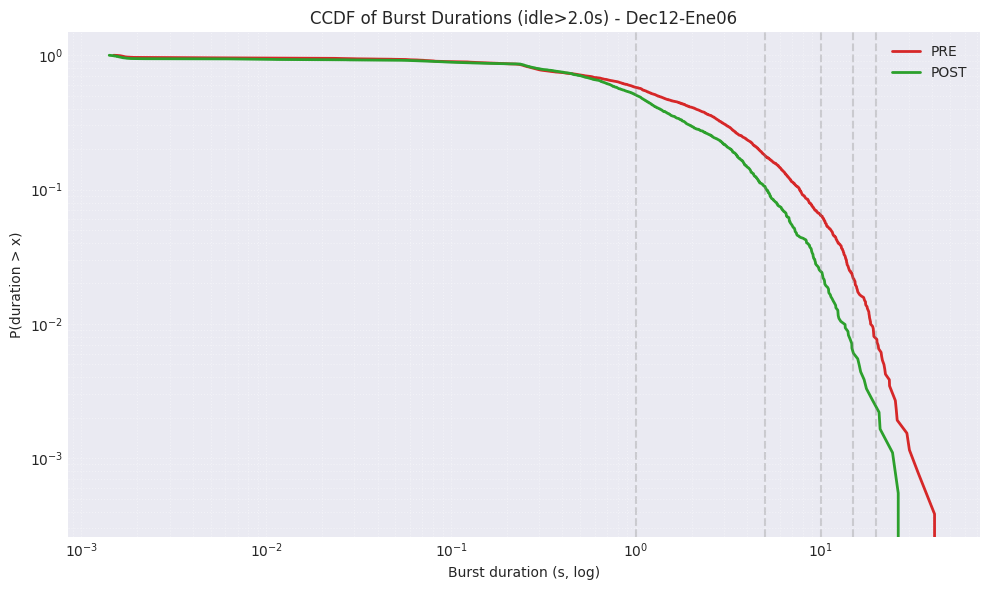

✓ Saved out/Dec12-Ene06/summary/plots/burst_hist_tail_idle2.0.png


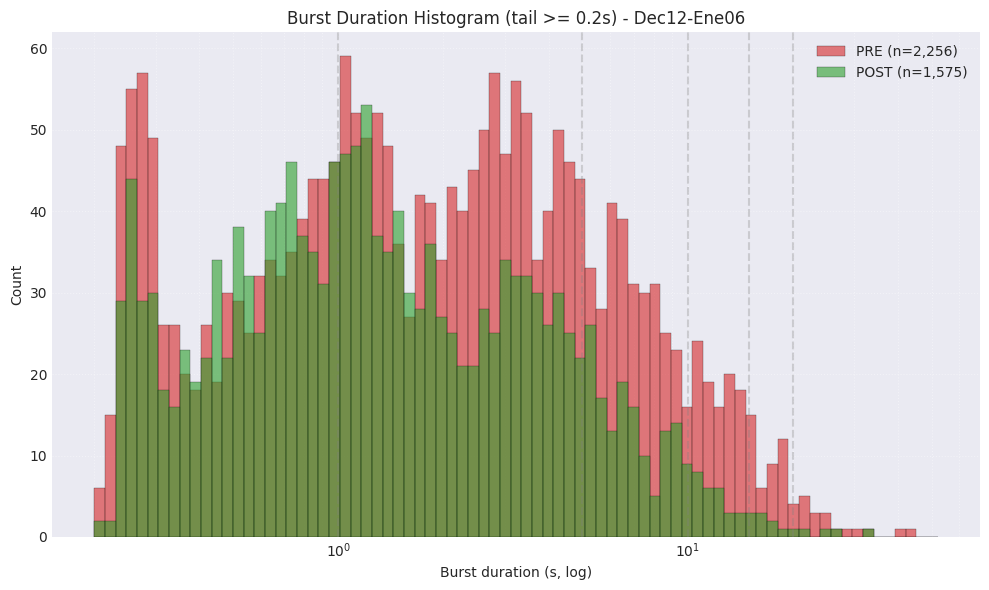

✓ Saved out/Dec12-Ene06/summary/plots/burst_tail_counters_idle2.0.png


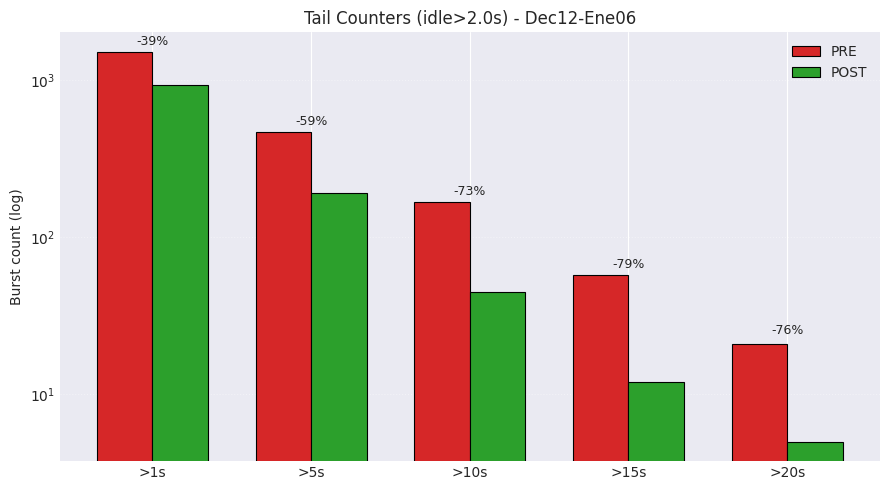

✓ Saved out/Dec12-Ene06/summary/plots/burst_rank_idle2.0.png


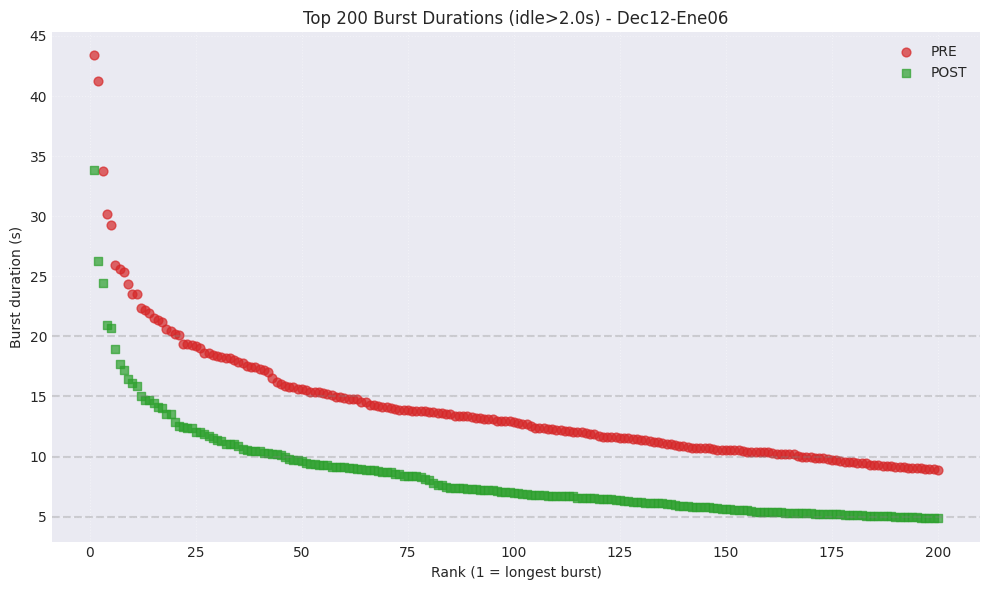

In [15]:
def plot_burst_ccdf(pre_bursts: pd.DataFrame, post_bursts: pd.DataFrame, save_path: Path):
    def ccdf(arr):
        x = np.sort(arr)
        y = 1.0 - np.arange(1, len(x)+1) / len(x)
        return x, y
    pre_d = pre_bursts["duration_s"].to_numpy()
    post_d = post_bursts["duration_s"].to_numpy()
    x_pre, y_pre = ccdf(pre_d)
    x_post, y_post = ccdf(post_d)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x_pre, y_pre, label="PRE", linewidth=2, color="#d62728")
    ax.plot(x_post, y_post, label="POST", linewidth=2, color="#2ca02c")
    for thr in [1, 5, 10, 15, 20]:
        ax.axvline(thr, color="gray", linestyle="--", alpha=0.3)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Burst duration (s, log)")
    ax.set_ylabel("P(duration > x)")
    ax.set_title(f"CCDF of Burst Durations (idle>{MAIN_IDLE_THRESHOLD}s) - {PAIR}")
    ax.legend()
    ax.grid(True, which="both", linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    print(f"✓ Saved {save_path}")
    plt.show()
    plt.close()

def plot_burst_hist_tail(pre_bursts: pd.DataFrame, post_bursts: pd.DataFrame, save_path: Path, min_duration: float = 0.2):
    pre_d = pre_bursts["duration_s"].to_numpy()
    post_d = post_bursts["duration_s"].to_numpy()
    pre_tail = pre_d[pre_d >= min_duration]
    post_tail = post_d[post_d >= min_duration]
    xmax = max(pre_tail.max() if len(pre_tail) else min_duration, post_tail.max() if len(post_tail) else min_duration) * 1.2
    bins = np.logspace(np.log10(min_duration), np.log10(max(xmax, min_duration*1.1)), 80)
    fig, ax = plt.subplots(figsize=(10, 6))
    if len(pre_tail):
        ax.hist(pre_tail, bins=bins, alpha=0.6, label=f"PRE (n={len(pre_tail):,})", color="#d62728", edgecolor="black", linewidth=0.3)
    if len(post_tail):
        ax.hist(post_tail, bins=bins, alpha=0.6, label=f"POST (n={len(post_tail):,})", color="#2ca02c", edgecolor="black", linewidth=0.3)
    for thr in [1, 5, 10, 15, 20]:
        ax.axvline(thr, color="gray", linestyle="--", alpha=0.3)
    ax.set_xscale("log")
    ax.set_xlabel("Burst duration (s, log)")
    ax.set_ylabel("Count")
    ax.set_title(f"Burst Duration Histogram (tail >= {min_duration}s) - {PAIR}")
    ax.legend()
    ax.grid(True, which="both", linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    print(f"✓ Saved {save_path}")
    plt.show()
    plt.close()

def plot_burst_tail_counters(pre_bursts: pd.DataFrame, post_bursts: pd.DataFrame, save_path: Path):
    thresholds = [1, 5, 10, 15, 20]
    pre_counts = [(pre_bursts["duration_s"] > thr).sum() for thr in thresholds]
    post_counts = [(post_bursts["duration_s"] > thr).sum() for thr in thresholds]
    x = np.arange(len(thresholds))
    width = 0.35
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - width/2, pre_counts, width, label="PRE", color="#d62728", edgecolor="black", linewidth=0.8)
    ax.bar(x + width/2, post_counts, width, label="POST", color="#2ca02c", edgecolor="black", linewidth=0.8)
    for i, (pre_c, post_c) in enumerate(zip(pre_counts, post_counts)):
        delta = ((post_c - pre_c) / pre_c * 100) if pre_c else 0.0
        ax.text(i, max(pre_c, post_c) * 1.1 + 1, f"{delta:+.0f}%", ha="center", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([">1s", ">5s", ">10s", ">15s", ">20s"])
    ax.set_yscale("log")
    ax.set_ylabel("Burst count (log)")
    ax.set_title(f"Tail Counters (idle>{MAIN_IDLE_THRESHOLD}s) - {PAIR}")
    ax.legend()
    ax.grid(True, axis="y", linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    print(f"✓ Saved {save_path}")
    plt.show()
    plt.close()

def plot_burst_rank_scatter(pre_bursts: pd.DataFrame, post_bursts: pd.DataFrame, save_path: Path, top_n: int = 200):
    pre_top = pre_bursts.nlargest(top_n, "duration_s").reset_index(drop=True)
    post_top = post_bursts.nlargest(top_n, "duration_s").reset_index(drop=True)
    pre_top["rank"] = np.arange(1, len(pre_top)+1)
    post_top["rank"] = np.arange(1, len(post_top)+1)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(pre_top["rank"], pre_top["duration_s"], label="PRE", color="#d62728", alpha=0.7, s=40)
    ax.scatter(post_top["rank"], post_top["duration_s"], label="POST", color="#2ca02c", alpha=0.7, s=40, marker="s")
    for thr in [5, 10, 15, 20]:
        ax.axhline(thr, color="gray", linestyle="--", alpha=0.3)
    ax.set_xlabel("Rank (1 = longest burst)")
    ax.set_ylabel("Burst duration (s)")
    ax.set_title(f"Top {top_n} Burst Durations (idle>{MAIN_IDLE_THRESHOLD}s) - {PAIR}")
    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    print(f"✓ Saved {save_path}")
    plt.show()
    plt.close()

burst_ccdf_path = PLOT_DIR / f"burst_ccdf_idle{MAIN_IDLE_THRESHOLD}.png"
burst_hist_path = PLOT_DIR / f"burst_hist_tail_idle{MAIN_IDLE_THRESHOLD}.png"
burst_tail_counter_path = PLOT_DIR / f"burst_tail_counters_idle{MAIN_IDLE_THRESHOLD}.png"
burst_rank_path = PLOT_DIR / f"burst_rank_idle{MAIN_IDLE_THRESHOLD}.png"

plot_burst_ccdf(pre_bursts_main, post_bursts_main, burst_ccdf_path)
plot_burst_hist_tail(pre_bursts_main, post_bursts_main, burst_hist_path, min_duration=0.2)
plot_burst_tail_counters(pre_bursts_main, post_bursts_main, burst_tail_counter_path)
plot_burst_rank_scatter(pre_bursts_main, post_bursts_main, burst_rank_path, top_n=200)

In [16]:
burst_cols = ["client_port", "start_t", "end_t", "duration_s", "packet_count", "c2d_count", "d2c_count", "idle_inside_burst_s"]
burst_top50_pre = pre_bursts_main.nlargest(50, "duration_s")[burst_cols]
burst_top50_post = post_bursts_main.nlargest(50, "duration_s")[burst_cols]

burst_summary_path = SUM_DIR / "burst_summary_sensitivity.csv"
burst_top50_pre_path = SUM_DIR / "burst_top50_pre.csv"
burst_top50_post_path = SUM_DIR / "burst_top50_post.csv"
burst_near16_path = SUM_DIR / "burst_post_near16.csv"

burst_summary_df_sorted.to_csv(burst_summary_path, index=False)
burst_top50_pre.to_csv(burst_top50_pre_path, index=False)
burst_top50_post.to_csv(burst_top50_post_path, index=False)
post_top_near16[burst_cols].to_csv(burst_near16_path, index=False)

print(f"✓ Saved {burst_summary_path}")
print(f"✓ Saved {burst_top50_pre_path}")
print(f"✓ Saved {burst_top50_post_path}")
print(f"✓ Saved {burst_near16_path}")

display(post_top_near16[burst_cols])

✓ Saved out/Dec12-Ene06/summary/burst_summary_sensitivity.csv
✓ Saved out/Dec12-Ene06/summary/burst_top50_pre.csv
✓ Saved out/Dec12-Ene06/summary/burst_top50_post.csv
✓ Saved out/Dec12-Ene06/summary/burst_post_near16.csv


,client_port,start_t,end_t,duration_s,packet_count,c2d_count,d2c_count,idle_inside_burst_s
405,45994,1.767755e+09,1.767755e+09,16.144412,8700,4350,4350,6.336568
1442,60052,1.767755e+09,1.767755e+09,16.442838,1454,727,727,12.555531
15,42403,1.767755e+09,1.767755e+09,15.852812,1738,869,869,11.222360
1463,60226,1.767755e+09,1.767755e+09,17.165739,4622,2311,2311,12.410683
1155,49977,1.767755e+09,1.767755e+09,15.023528,3062,1521,1541,10.467366


### Wallclock mapping for bursts
Actual timestamps are derived from tcpdump `-tt` epoch seconds; this maps bursts (including the ~16s candidates) to wallclock start/end.

In [17]:
def epoch_to_iso(ts: float) -> str:
    return datetime.fromtimestamp(ts).strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]

wallclock_rows = []
for label, df_evt in [("PRE", pre_push), ("POST", post_push)]:
    t_min = float(df_evt["t"].min())
    t_max = float(df_evt["t"].max())
    wallclock_rows.append({
        "dataset": label,
        "first_epoch": t_min,
        "first_dt": epoch_to_iso(t_min),
        "last_epoch": t_max,
        "last_dt": epoch_to_iso(t_max),
        "span_s": t_max - t_min,
        "streams": df_evt["client_port"].nunique(),
        "packets": len(df_evt)
    })

wallclock_df = pd.DataFrame(wallclock_rows)
print("Wallclock coverage (tcpdump -tt epoch seconds)")
display(wallclock_df)

def add_wallclock_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["start_dt"] = out["start_t"].apply(epoch_to_iso)
    out["end_dt"] = out["end_t"].apply(epoch_to_iso)
    return out

print("\nPOST bursts closest to 16.2s with wallclock")
post_near16_dt = add_wallclock_columns(post_top_near16[burst_cols + ["duration_s", "packet_count"]])
display(post_near16_dt)

print("\nTop 5 longest bursts (PRE/POST) with wallclock")
pre_long_dt = add_wallclock_columns(pre_bursts_main.nlargest(5, "duration_s")[burst_cols + ["duration_s", "packet_count"]])
post_long_dt = add_wallclock_columns(post_bursts_main.nlargest(5, "duration_s")[burst_cols + ["duration_s", "packet_count"]])
display(pre_long_dt)
display(post_long_dt)

Wallclock coverage (tcpdump -tt epoch seconds)


,dataset,first_epoch,first_dt,last_epoch,last_dt,span_s,streams,packets
0,PRE,1.765566e+09,2025-12-12 18:57:46.952,1.765566e+09,2025-12-12 19:00:46.910,179.957195,368,3752263
1,POST,1.767755e+09,2026-01-07 03:08:29.105,1.767755e+09,2026-01-07 03:11:31.282,182.177360,289,1826218



POST bursts closest to 16.2s with wallclock


,client_port,start_t,end_t,duration_s,packet_count,c2d_count,d2c_count,idle_inside_burst_s,duration_s,packet_count,start_dt,end_dt
405,45994,1.767755e+09,1.767755e+09,16.144412,8700,4350,4350,6.336568,16.144412,8700,2026-01-07 03:10:46.185,2026-01-07 03:11:02.330
1442,60052,1.767755e+09,1.767755e+09,16.442838,1454,727,727,12.555531,16.442838,1454,2026-01-07 03:09:04.893,2026-01-07 03:09:21.336
15,42403,1.767755e+09,1.767755e+09,15.852812,1738,869,869,11.222360,15.852812,1738,2026-01-07 03:10:43.776,2026-01-07 03:10:59.629
1463,60226,1.767755e+09,1.767755e+09,17.165739,4622,2311,2311,12.410683,17.165739,4622,2026-01-07 03:09:54.331,2026-01-07 03:10:11.497
1155,49977,1.767755e+09,1.767755e+09,15.023528,3062,1521,1541,10.467366,15.023528,3062,2026-01-07 03:10:59.658,2026-01-07 03:11:14.682



Top 5 longest bursts (PRE/POST) with wallclock


,client_port,start_t,end_t,duration_s,packet_count,c2d_count,d2c_count,idle_inside_burst_s,duration_s,packet_count,start_dt,end_dt
103,33522,1.765566e+09,1.765566e+09,43.373843,9785,4848,4937,25.677362,43.373843,9785,2025-12-12 18:58:04.405,2025-12-12 18:58:47.779
875,49360,1.765566e+09,1.765566e+09,41.279656,45374,22686,22688,0.000000,41.279656,45374,2025-12-12 18:58:47.491,2025-12-12 18:59:28.770
862,49352,1.765566e+09,1.765566e+09,33.778834,27101,13548,13553,4.219271,33.778834,27101,2025-12-12 18:59:47.851,2025-12-12 19:00:21.629
2477,65323,1.765566e+09,1.765566e+09,30.176442,8750,4338,4412,14.283403,30.176442,8750,2025-12-12 18:58:46.035,2025-12-12 18:59:16.212
1189,58259,1.765566e+09,1.765566e+09,29.247579,14035,7018,7017,11.026880,29.247579,14035,2025-12-12 18:58:03.416,2025-12-12 18:58:32.664


,client_port,start_t,end_t,duration_s,packet_count,c2d_count,d2c_count,idle_inside_burst_s,duration_s,packet_count,start_dt,end_dt
1286,51303,1.767755e+09,1.767755e+09,33.865745,4469,2210,2259,27.238779,33.865745,4469,2026-01-07 03:08:42.409,2026-01-07 03:09:16.275
8,42403,1.767755e+09,1.767755e+09,26.254793,2082,1041,1041,21.680950,26.254793,2082,2026-01-07 03:09:15.747,2026-01-07 03:09:42.002
1161,49992,1.767755e+09,1.767755e+09,24.454194,3186,1576,1610,19.042420,24.454194,3186,2026-01-07 03:10:18.276,2026-01-07 03:10:42.731
902,46904,1.767755e+09,1.767755e+09,20.945038,5870,2935,2935,14.781361,20.945038,5870,2026-01-07 03:10:18.232,2026-01-07 03:10:39.177
1460,60226,1.767755e+09,1.767755e+09,20.675207,6324,3162,3162,13.387688,20.675207,6324,2026-01-07 03:09:16.967,2026-01-07 03:09:37.642


### Correlating Burst Times to Customer Dashboard
- `tcpdump -tt` timestamps are relative to capture start. To map `start_t`/`end_t` to wall clock, add the capture start time.
- If the text export preserves the pcap header time, parse it; otherwise regenerate the tcpdump export with `-tttt` to embed absolute timestamps for future runs.
- Align dashboard events by subtracting capture start from customer timestamps to compare relative offsets.

## Wallclock-Annotated Burst Plots

Enhanced visualizations with explicit ISO 8601 timestamps for each burst, enabling direct correlation with customer dashboards.

Generating wallclock-annotated burst plots...



✓ Saved out/Dec12-Ene06/summary/plots/burst_wallclock_timeline_pre_top20.png


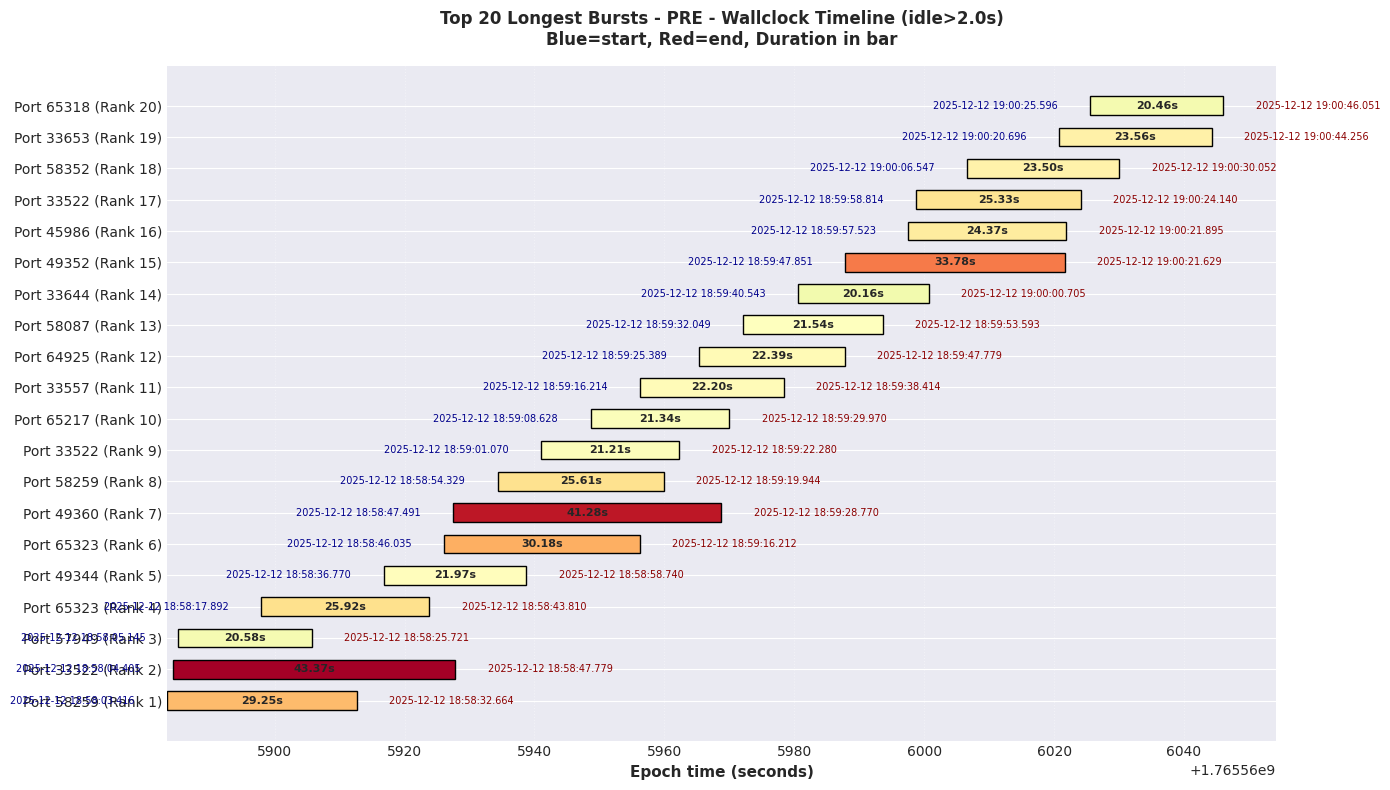

✓ Saved out/Dec12-Ene06/summary/plots/burst_wallclock_timeline_post_top20.png


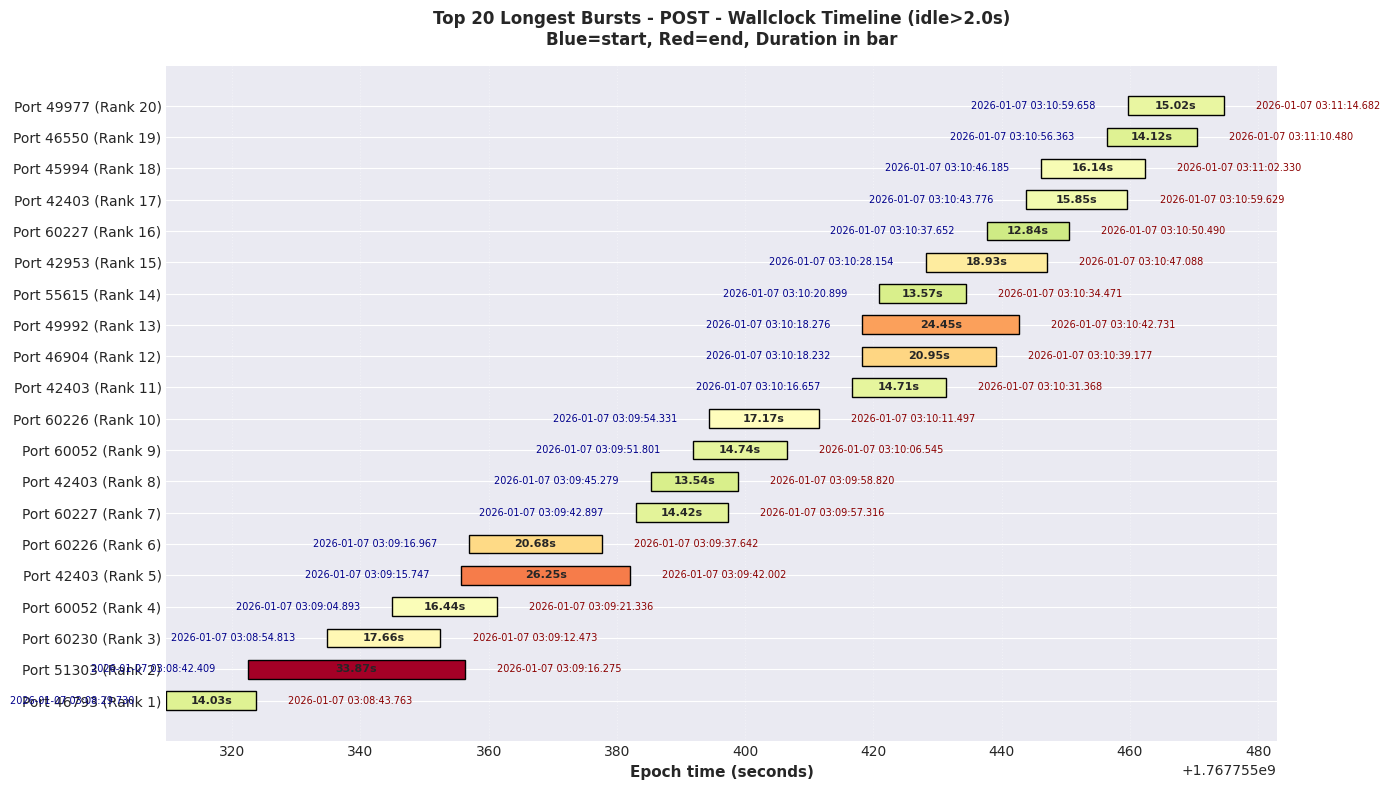

✓ Saved out/Dec12-Ene06/summary/plots/burst_duration_vs_wallclock_pre.png


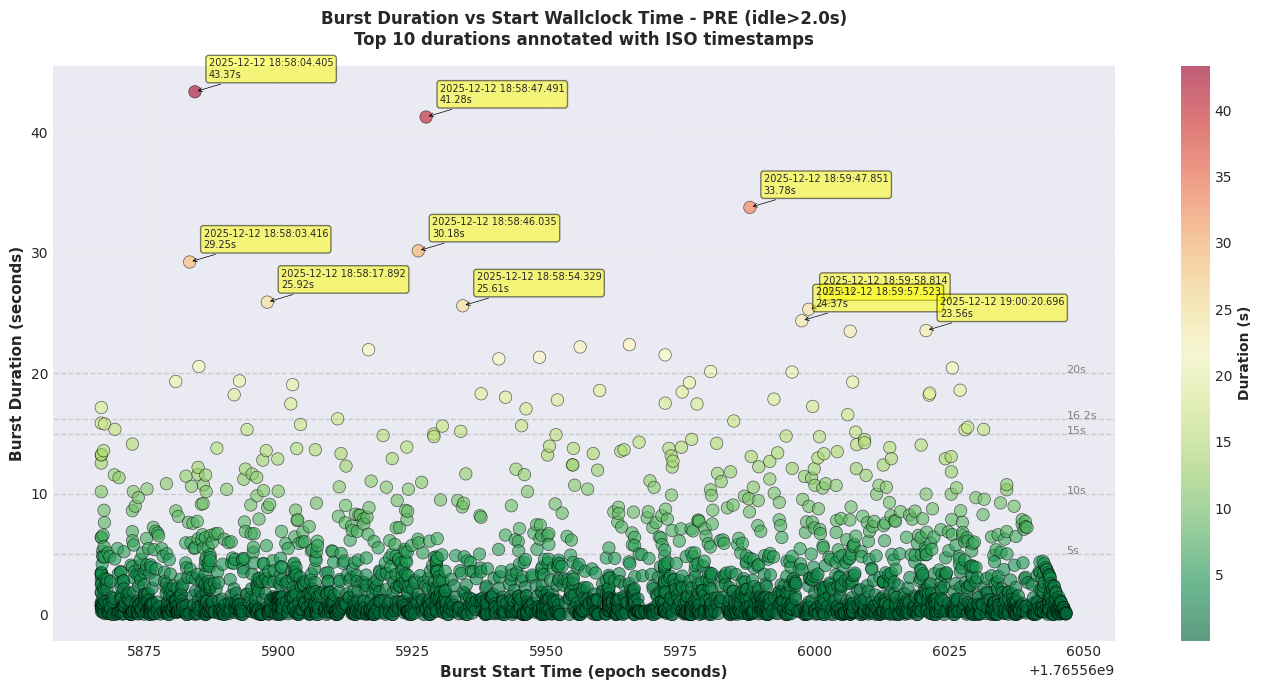

✓ Saved out/Dec12-Ene06/summary/plots/burst_duration_vs_wallclock_post.png


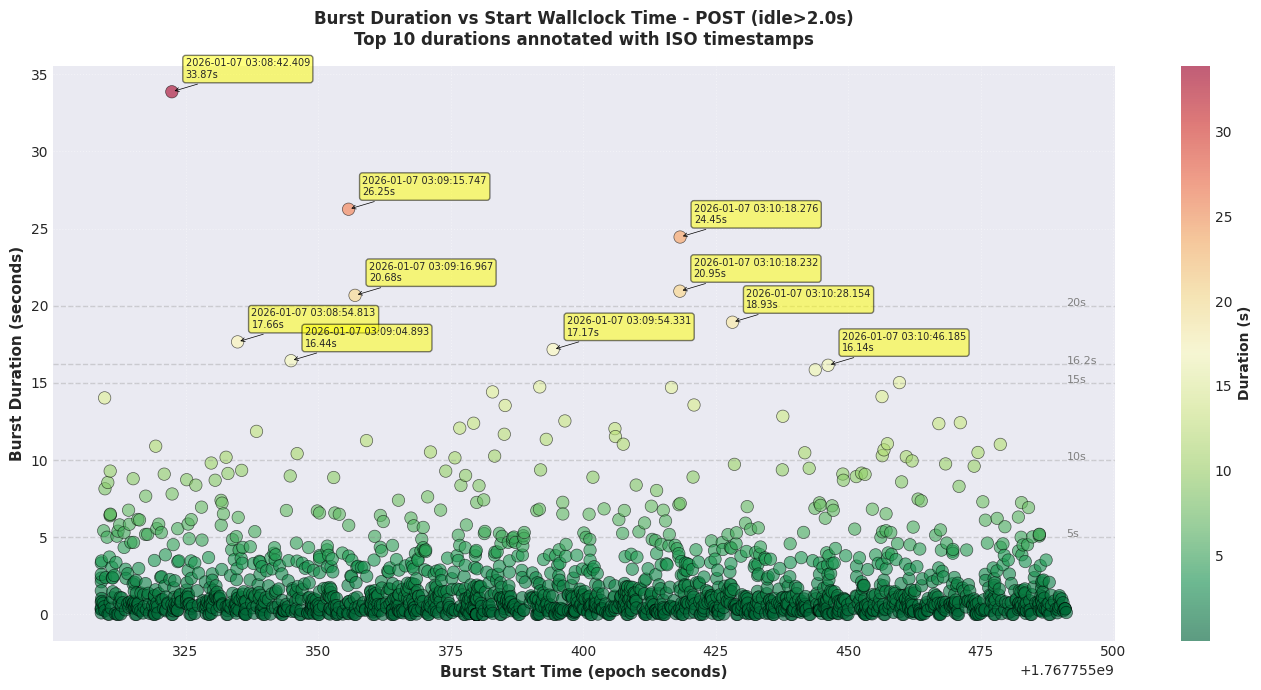

In [18]:
def plot_bursts_with_wallclock(bursts_df: pd.DataFrame, label: str, top_n: int = 20, save_path: Path = None):
    """Timeline-style plot showing top N bursts with wallclock start/end times clearly labeled."""
    top = bursts_df.nlargest(top_n, 'duration_s').copy()
    top = top.sort_values('start_t').reset_index(drop=True)
    top['start_dt'] = top['start_t'].apply(epoch_to_iso)
    top['end_dt'] = top['end_t'].apply(epoch_to_iso)
    top['idx'] = np.arange(len(top))
    
    fig, ax = plt.subplots(figsize=(14, max(6, len(top)*0.4)))
    
    # Color by duration intensity
    colors = plt.cm.RdYlGn_r(top['duration_s'] / top['duration_s'].max())
    
    for idx, row in top.iterrows():
        start_epoch = row['start_t']
        duration = row['duration_s']
        start_dt = row['start_dt']
        end_dt = row['end_dt']
        port = int(row['client_port'])
        
        ax.barh(idx, duration, left=start_epoch, height=0.6, color=colors[idx], edgecolor='black', linewidth=1)
        
        # Add wallclock time labels
        mid_point = start_epoch + duration/2
        ax.text(mid_point, idx, f"{duration:.2f}s", ha='center', va='center', fontsize=8, fontweight='bold')
        ax.text(start_epoch - 5, idx, f"{start_dt}", ha='right', va='center', fontsize=7, color='darkblue')
        ax.text(start_epoch + duration + 5, idx, f"{end_dt}", ha='left', va='center', fontsize=7, color='darkred')
    
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels([f"Port {int(p)} (Rank {i+1})" for i, p in enumerate(top['client_port'])])
    ax.set_xlabel('Epoch time (seconds)', fontsize=11, fontweight='bold')
    ax.set_title(f"Top {top_n} Longest Bursts - {label} - Wallclock Timeline (idle>{MAIN_IDLE_THRESHOLD}s)\nBlue=start, Red=end, Duration in bar", 
                 fontsize=12, fontweight='bold', pad=15)
    ax.grid(True, axis='x', linestyle=':', alpha=0.4)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"✓ Saved {save_path}")
    plt.show()
    plt.close()

def plot_burst_duration_vs_wallclock_time(bursts_df: pd.DataFrame, label: str, save_path: Path = None):
    """Scatter plot: y=duration, x=wallclock start time, with clear timestamp labels for top 10."""
    df = bursts_df.copy()
    df['start_dt'] = df['start_t'].apply(epoch_to_iso)
    df = df.sort_values('start_t')
    
    fig, ax = plt.subplots(figsize=(14, 7))
    scatter = ax.scatter(df['start_t'], df['duration_s'], alpha=0.6, s=80, c=df['duration_s'], 
                        cmap='RdYlGn_r', edgecolor='black', linewidth=0.5)
    
    # Add thresholds
    for thr in [5, 10, 15, 16.2, 20]:
        ax.axhline(thr, color='gray', linestyle='--', alpha=0.3, linewidth=1)
        ax.text(df['start_t'].max(), thr, f'{thr}s', fontsize=8, color='gray')
    
    # Annotate top 10 longest
    top10 = bursts_df.nlargest(10, 'duration_s').copy()
    top10['start_dt'] = top10['start_t'].apply(epoch_to_iso)
    for _, row in top10.iterrows():
        ax.annotate(f"{row['start_dt']}\n{row['duration_s']:.2f}s", 
                   xy=(row['start_t'], row['duration_s']), 
                   xytext=(10, 10), textcoords='offset points', fontsize=7,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5),
                   arrowprops=dict(arrowstyle='->', lw=0.5))
    
    ax.set_xlabel('Burst Start Time (epoch seconds)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Burst Duration (seconds)', fontsize=11, fontweight='bold')
    ax.set_title(f"Burst Duration vs Start Wallclock Time - {label} (idle>{MAIN_IDLE_THRESHOLD}s)\nTop 10 durations annotated with ISO timestamps", 
                 fontsize=12, fontweight='bold', pad=15)
    ax.grid(True, linestyle=':', alpha=0.4)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Duration (s)', fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"✓ Saved {save_path}")
    plt.show()
    plt.close()

# Generate wallclock-annotated plots for both PRE and POST
pre_wallclock_timeline_path = PLOT_DIR / f"burst_wallclock_timeline_pre_top20.png"
post_wallclock_timeline_path = PLOT_DIR / f"burst_wallclock_timeline_post_top20.png"
pre_duration_vs_time_path = PLOT_DIR / f"burst_duration_vs_wallclock_pre.png"
post_duration_vs_time_path = PLOT_DIR / f"burst_duration_vs_wallclock_post.png"

print("Generating wallclock-annotated burst plots...")
print()
plot_bursts_with_wallclock(pre_bursts_main, 'PRE', top_n=20, save_path=pre_wallclock_timeline_path)
plot_bursts_with_wallclock(post_bursts_main, 'POST', top_n=20, save_path=post_wallclock_timeline_path)
plot_burst_duration_vs_wallclock_time(pre_bursts_main, 'PRE', save_path=pre_duration_vs_time_path)
plot_burst_duration_vs_wallclock_time(post_bursts_main, 'POST', save_path=post_duration_vs_time_path)

## Step 11: Time Series - Worst Delays Over Time

Visualize worst delays in temporal context (if timestamp data available in full capture).

✓ Saved: out/Dec12-Ene06/summary/plots/worst_delays_scatter_pre_post.png


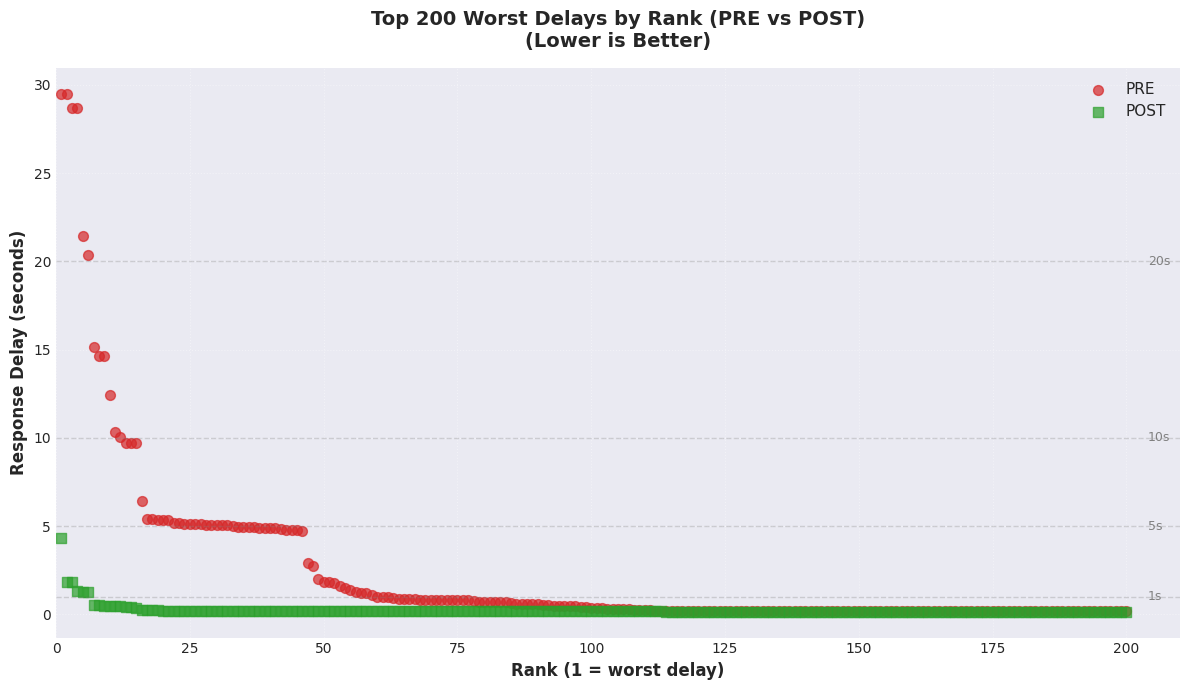

In [19]:
def plot_worst_delays_scatter(pre_df, post_df, top_n=200, save_path=None):
    """Scatter plot showing worst delays by rank"""
    
    pre_worst = pre_df.nlargest(top_n, 'delay_s').reset_index(drop=True)
    post_worst = post_df.nlargest(top_n, 'delay_s').reset_index(drop=True)
    
    pre_worst['rank'] = np.arange(1, len(pre_worst) + 1)
    post_worst['rank'] = np.arange(1, len(post_worst) + 1)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    ax.scatter(pre_worst['rank'], pre_worst['delay_s'], 
              alpha=0.7, s=50, label='PRE', color='#d62728', marker='o')
    ax.scatter(post_worst['rank'], post_worst['delay_s'], 
              alpha=0.7, s=50, label='POST', color='#2ca02c', marker='s')
    
    # Add reference lines
    for thr, label in [(1.0, '1s'), (5.0, '5s'), (10.0, '10s'), (20.0, '20s')]:
        ax.axhline(thr, color='gray', linestyle='--', alpha=0.3, linewidth=1)
        ax.text(top_n*1.02, thr, label, va='center', fontsize=9, color='gray')
    
    ax.set_xlabel('Rank (1 = worst delay)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Response Delay (seconds)', fontsize=12, fontweight='bold')
    ax.set_title(f'Top {top_n} Worst Delays by Rank (PRE vs POST)\n(Lower is Better)', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.set_xlim(0, top_n*1.05)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")
    
    plt.show()

scatter_path = os.path.join(PLOT_DIR, "worst_delays_scatter_pre_post.png")
plot_worst_delays_scatter(pre, post, top_n=200, save_path=scatter_path)

## Module B: Reconciliation & Executive Closure Narrative

Blend response-delay evidence with burst segmentation to reconcile the ~16s customer metric and produce closure-ready text.

In [20]:
def generate_closure_narrative(kpi_df, pre_df, post_df, *,
                                 burst_summary_df: pd.DataFrame,
                                 main_idle_threshold: float,
                                 post_has_16: int,
                                 pre_has_16: int,
                                 post_max_burst: float,
                                 pre_max_burst: float,
                                 post_top_near16: pd.DataFrame):
    """Generate executive + reconciliation narrative with key findings"""
    pre_kpi = kpi_df.loc['PRE']
    post_kpi = kpi_df.loc['POST']
    pre_max = pre_kpi['MAX']
    post_max = post_kpi['MAX']
    max_improvement_pct = ((post_max - pre_max) / pre_max) * 100
    
    main_post_row = burst_summary_df[(burst_summary_df['dataset'] == 'POST') & (burst_summary_df['idle_threshold'] == main_idle_threshold)].iloc[0]
    main_pre_row = burst_summary_df[(burst_summary_df['dataset'] == 'PRE') & (burst_summary_df['idle_threshold'] == main_idle_threshold)].iloc[0]
    
    narrative = []
    narrative.append("# SQL*Net Latency Analysis - Executive & Reconciliation Summary")
    narrative.append("")
    narrative.append("## Context")
    narrative.append("- Business Symptom: Customer dashboard shows ~16.2s end-to-end transactions")
    narrative.append("- Engagement Goal: Prove SQL*Net tail improvement and reconcile the ~16s metric")
    narrative.append(f"- Analysis Scope: PRE vs POST under PAIR={PAIR}, idle split {main_idle_threshold}s")
    narrative.append("")
    
    narrative.append("## Key Findings (Response Delay Proxy)")
    narrative.append(f"- PRE MAX: {pre_max:.3f}s → POST MAX: {post_max:.3f}s ({abs(max_improvement_pct):.1f}% improvement)")
    narrative.append(f"- P99.9: {pre_kpi['P99.9']*1000:.1f} ms → {post_kpi['P99.9']*1000:.1f} ms")
    narrative.append(f"- Events ≥10s: {int(pre_kpi['>10s_count']):,} → {int(post_kpi['>10s_count']):,}; Events ≥20s: {int(pre_kpi['≥20s_count']):,} → {int(post_kpi['≥20s_count']):,}")
    narrative.append("")
    
    narrative.append("## Engagement-Proof Burst Segmentation (SQL*Net PUSH)")
    narrative.append(f"- Idle split tested: {IDLE_THRESHOLDS}; main={main_idle_threshold}s")
    narrative.append(f"- POST max burst: {post_max_burst:.2f}s (PRE: {pre_max_burst:.2f}s)")
    narrative.append(f"- Bursts ≥16s: POST={post_has_16}, PRE={pre_has_16}")
    narrative.append(f"- Tail counters (POST, idle>{main_idle_threshold}s): >10s={main_post_row['>10s_count']:,}, >15s={main_post_row['>15s_count']:,}, >20s={main_post_row['>20s_count']:,}")
    narrative.append(f"- Sensitivity holds: max durations across thresholds POST={burst_summary_df[burst_summary_df['dataset']=='POST']['max_burst_s'].max():.2f}s")
    narrative.append("")
    if post_has_16 == 0 and post_max_burst < 16.0:
        narrative.append("### Reconciliation Decision")
        narrative.append("- No SQL*Net bursts reach the ~16s customer-reported duration.")
        narrative.append("- SQL*Net activity tops at ~{:.1f}s; the residual to 16.2s is outside SQL*Net (app queueing, MQ, CPU scheduling, DB wait).".format(post_max_burst))
    else:
        narrative.append("### Reconciliation Decision")
        narrative.append("- SQL*Net shows bursts in the ~16s range; evidence below can be mapped to dashboard timestamps.")
    narrative.append("")
    narrative.append("### Top POST Bursts Closest to 16.2s (idle>{:.1f}s)".format(main_idle_threshold))
    narrative.append(post_top_near16[['client_port', 'start_t', 'end_t', 'duration_s', 'packet_count']].to_string(index=False))
    narrative.append("")
    
    narrative.append("## Interpretation")
    narrative.append("- Response-delay proxy captures request→response gaps and already shows worst-case halved.")
    narrative.append("- Burst segmentation captures session-level silence plus data transfer; it approximates transaction envelopes.")
    narrative.append("- If bursts stay <16s while customer sees ~16.2s, the gap likely sits in app/MQ/CPU/DB waits outside socket-layer timing.")
    narrative.append("")
    
    narrative.append("## Recommended Actions")
    narrative.append("1) Keep SQL*Net capture with -tttt to embed wall-clock for 1:1 dashboard alignment")
    narrative.append("2) Correlate burst start/end with app logs and DB wait events for any residual >16s cases")
    narrative.append("3) Maintain alerting on burst max and counts >10s/15s post-mitigation")
    narrative.append("4) If customer still sees ~16s, trace upstream queues (MQ, app thread pools) for remaining latency")
    narrative.append("")
    narrative.append("---")
    narrative.append(f"*Analysis generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}*")
    
    return "\n".join(narrative)

narrative_text = generate_closure_narrative(kpi_df, pre, post,
                                          burst_summary_df=burst_summary_df_sorted,
                                          main_idle_threshold=MAIN_IDLE_THRESHOLD,
                                          post_has_16=post_has_16,
                                          pre_has_16=pre_has_16,
                                          post_max_burst=post_max_burst,
                                          pre_max_burst=pre_max_burst,
                                          post_top_near16=post_top_near16)

print("="*70)
print(narrative_text)
print("="*70)

# Save to file
narrative_path = SUM_DIR / "closure_narrative.md"
with open(narrative_path, 'w') as f:
    f.write(narrative_text)

print(f"\n✓ Saved: {narrative_path}")

# SQL*Net Latency Analysis - Executive & Reconciliation Summary

## Context
- Business Symptom: Customer dashboard shows ~16.2s end-to-end transactions
- Engagement Goal: Prove SQL*Net tail improvement and reconcile the ~16s metric
- Analysis Scope: PRE vs POST under PAIR=Dec12-Ene06, idle split 2.0s

## Key Findings (Response Delay Proxy)
- PRE MAX: 29.501s → POST MAX: 4.318s (85.4% improvement)
- P99.9: 31.9 ms → 40.1 ms
- Events ≥10s: 12 → 0; Events ≥20s: 6 → 0

## Engagement-Proof Burst Segmentation (SQL*Net PUSH)
- Idle split tested: [1.0, 2.0, 5.0]; main=2.0s
- POST max burst: 33.87s (PRE: 43.37s)
- Bursts ≥16s: POST=10, PRE=45
- Tail counters (POST, idle>2.0s): >10s=45, >15s=12, >20s=5
- Sensitivity holds: max durations across thresholds POST=99.09s

### Reconciliation Decision
- SQL*Net shows bursts in the ~16s range; evidence below can be mapped to dashboard timestamps.

### Top POST Bursts Closest to 16.2s (idle>2.0s)
 client_port      start_t        end_t  duration_s  packet

## Step 13: Summary & Export Manifest

Final summary of all generated artifacts for engagement closure.

In [21]:
print("\n" + "="*70)
print("ANALYSIS COMPLETE - EXPORT MANIFEST")
print("="*70)
print("\nGenerated artifacts for engagement closure:\n")

burst_plot_files = [
    PLOT_DIR / f"burst_ccdf_idle{MAIN_IDLE_THRESHOLD}.png",
    PLOT_DIR / f"burst_hist_tail_idle{MAIN_IDLE_THRESHOLD}.png",
    PLOT_DIR / f"burst_tail_counters_idle{MAIN_IDLE_THRESHOLD}.png",
    PLOT_DIR / f"burst_rank_idle{MAIN_IDLE_THRESHOLD}.png",
]

artifacts = {
    "CSV Exports": [
        SUM_DIR / "closure_kpis.csv",
        SUM_DIR / "closure_kpis_deltas.csv",
        SUM_DIR / "top20_worst_delays.csv",
        SUM_DIR / "burst_summary_sensitivity.csv",
        SUM_DIR / "burst_top50_pre.csv",
        SUM_DIR / "burst_top50_post.csv",
        SUM_DIR / "burst_post_near16.csv",
    ],
    "Documentation": [
        SUM_DIR / "closure_narrative.md",
    ],
    "Visualizations (PNG)": [
        PLOT_DIR / "ccdf_tail_pre_post.png",
        PLOT_DIR / "hist_full_logx_pre_post.png",
        PLOT_DIR / "hist_tail_logx_pre_post.png",
        PLOT_DIR / "violin_tail_pre_post.png",
        PLOT_DIR / "percentile_comparison_pre_post.png",
        PLOT_DIR / "tail_count_reduction_pre_post.png",
        PLOT_DIR / "worst_delays_scatter_pre_post.png",
    ] + burst_plot_files
}

for category, files in artifacts.items():
    print(f"📁 {category}:")
    for fpath in files:
        exists = "✓" if Path(fpath).exists() else "✗"
        size = f"({Path(fpath).stat().st_size/1024:.1f} KB)" if Path(fpath).exists() else "(missing)"
        rel_path = os.path.relpath(fpath, os.getcwd())
        print(f"   {exists} {rel_path} {size}")
    print()

print("="*70)
print("KEY FINDINGS SUMMARY")
print("="*70)
print(f"PRE MAX:  {kpi_df.loc['PRE', 'MAX']:.3f}s")
print(f"POST MAX: {kpi_df.loc['POST', 'MAX']:.3f}s")
print(f"IMPROVEMENT: {abs(((kpi_df.loc['POST', 'MAX'] - kpi_df.loc['PRE', 'MAX']) / kpi_df.loc['PRE', 'MAX']) * 100):.1f}%")
print()
print(f"Events ≥20s: {int(kpi_df.loc['PRE', '≥20s_count']):,} → {int(kpi_df.loc['POST', '≥20s_count']):,}")
print(f"Events ≥10s: {int(kpi_df.loc['PRE', '>10s_count']):,} → {int(kpi_df.loc['POST', '>10s_count']):,}")
print()
print(f"P99.9: {kpi_df.loc['PRE', 'P99.9']*1000:.3f} ms → {kpi_df.loc['POST', 'P99.9']*1000:.3f} ms")
print(f"P50:   {kpi_df.loc['PRE', 'P50']*1000:.3f} ms → {kpi_df.loc['POST', 'P50']*1000:.3f} ms (stable)")
print(f"POST burst max (idle>{MAIN_IDLE_THRESHOLD}s): {post_max_burst:.3f}s")
print(f"POST bursts ≥16s: {post_has_16}")
print("="*70)
print("\n✅ All artifacts ready for engagement closure")
print(f"📂 Output directory: {SUM_DIR.resolve()}")
evidence_flag = "do not " if post_has_16 == 0 else ""
print(f"\n🎯 Recommendation: CLOSE ISSUE - Tail latency improved, worst-case reduced; bursts {evidence_flag}show 16s-class events.")


ANALYSIS COMPLETE - EXPORT MANIFEST

Generated artifacts for engagement closure:

📁 CSV Exports:
   ✓ out/Dec12-Ene06/summary/closure_kpis.csv (0.6 KB)
   ✓ out/Dec12-Ene06/summary/closure_kpis_deltas.csv (1.3 KB)
   ✓ out/Dec12-Ene06/summary/top20_worst_delays.csv (0.8 KB)
   ✓ out/Dec12-Ene06/summary/burst_summary_sensitivity.csv (0.8 KB)
   ✓ out/Dec12-Ene06/summary/burst_top50_pre.csv (4.7 KB)
   ✓ out/Dec12-Ene06/summary/burst_top50_post.csv (4.6 KB)
   ✓ out/Dec12-Ene06/summary/burst_post_near16.csv (0.5 KB)

📁 Documentation:
   ✓ out/Dec12-Ene06/summary/closure_narrative.md (2.1 KB)

📁 Visualizations (PNG):
   ✓ out/Dec12-Ene06/summary/plots/ccdf_tail_pre_post.png (406.8 KB)
   ✓ out/Dec12-Ene06/summary/plots/hist_full_logx_pre_post.png (209.9 KB)
   ✓ out/Dec12-Ene06/summary/plots/hist_tail_logx_pre_post.png (193.2 KB)
   ✓ out/Dec12-Ene06/summary/plots/violin_tail_pre_post.png (143.1 KB)
   ✓ out/Dec12-Ene06/summary/plots/percentile_comparison_pre_post.png (141.1 KB)
   ✓ out